In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:85% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:12pt;}
div.output {font-size:12pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:12pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:12px;}
</style>
"""))

# 1. 패키지로드 & 한글설정 & 경고메세지 ignore

In [60]:
# 패키지 import
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 시각화의 선명도를 높임
%config InlineBackend.figure_format = "retina"
# from IPython.display import set_matplotlib_formats
# set_matplotlib_formats('retina')

from matplotlib.font_manager import FontProperties, fontManager
font_path = r"C:\Users\Admin\Downloads\JMK체.ttf"
fontManager.addfont(font_path)
font_prop = FontProperties(fname=font_path, size=12)
font_name = font_prop.get_name()

# 한글설정
sns.set(
    style="white",
    context="notebook",
    palette="Dark2",
    rc={
        "figure.figsize": (12, 3),
        "font.family": font_name,  # 한글 폰트 지정
        "axes.unicode_minus": False,  # 마이너스 부호 깨짐 방지
    },
)

# warning(경고) 안보이게
import warnings
# warnings.filterwarnings(action='ignore') # 경고 메세지 안보이게
# warnings.filterwarnings(action='default') # 경고 메세지 보이게

# 2. 서울과 부산를 df변수에 불러오기

In [6]:
# 큰 용량의 데이터 불러오기 시 발생하는 타입 에러 해결방법 1
df_seoul = pd.read_csv(r"C:\ai\downloads\shareData\상가정보\소상공인시장진흥공단_상가(상권)정보_서울_202603.csv", 
                       low_memory=False # 파일을 chunk 단위로 나누지 않고, 전체 내용을 한번에 불러옴 => 타입 일관성 유지
                      )
df_seoul.shape

(537489, 39)

In [8]:
# 큰 용량의 데이터 불러오기 시 발생하는 타입 에러 해결방법 2 : 방법 1에 비하여 메모리 관리 효율이 높음
df_seoul = pd.read_csv(r"C:\ai\downloads\shareData\상가정보\소상공인시장진흥공단_상가(상권)정보_서울_202603.csv", 
                       dtype={'층정보':str} # 에러가 발생한 위치에 대해 타입을 지정 => 타입 일관성 유지
                      )
df_seoul.shape

(537489, 39)

In [11]:
df_seoul['층정보'].unique()[10:20] # 일반적인 read_csv로 chunk 단위로 불러올 시, float과 str이 혼재됨

array(['지', '24', '14', '402', '10', '12', '7', '17', '13', '18'],
      dtype=object)

In [5]:
# 상세 메모리 사용량
df_seoul.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 537489 entries, 0 to 537488
Data columns (total 39 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   상가업소번호     537489 non-null  object 
 1   상호명        537489 non-null  object 
 2   지점명        47001 non-null   object 
 3   상권업종대분류코드  537489 non-null  object 
 4   상권업종대분류명   537489 non-null  object 
 5   상권업종중분류코드  537489 non-null  object 
 6   상권업종중분류명   537489 non-null  object 
 7   상권업종소분류코드  537489 non-null  object 
 8   상권업종소분류명   537489 non-null  object 
 9   표준산업분류코드   537291 non-null  object 
 10  표준산업분류명    537291 non-null  object 
 11  시도코드       537489 non-null  int64  
 12  시도명        537489 non-null  object 
 13  시군구코드      537489 non-null  int64  
 14  시군구명       537489 non-null  object 
 15  행정동코드      537489 non-null  int64  
 16  행정동명       537489 non-null  object 
 17  법정동코드      537489 non-null  int64  
 18  법정동명       537489 non-null  object 
 19  지번코드       537489 non-n

In [13]:
df_busan = pd.read_csv(r"C:\ai\downloads\shareData\상가정보\소상공인시장진흥공단_상가(상권)정보_부산_202603.csv", 
                       dtype={'층정보':str})
df_busan.shape

(155103, 39)

In [14]:
df_busan.head(1).T

,0
상가업소번호,MA010120220804863915
상호명,제이와이솔루션
지점명,NaN
상권업종대분류코드,G2
상권업종대분류명,소매
상권업종중분류코드,G215
상권업종중분류명,의약·화장품 소매
상권업종소분류코드,G21502
상권업종소분류명,의료기기 소매업
표준산업분류코드,G47812


In [ ]:
# 서울시 소상공인 데이터와 부산시 소상공인 데이터 concat을 위한 준비

In [17]:
# 컬럼명 일치 여부 확인
np.all(df_seoul.columns == df_busan.columns)

True

In [40]:
# 컬럼 타입 일치 여부 확인 - 건물본번지 불일치 확인 / 서울 - float64, 부산 - int64
np.all(df_seoul.dtypes == df_busan.dtypes)

False

In [37]:
df_seoul['건물본번지'].dtype

dtype('float64')

In [39]:
df_busan['건물본번지'].astype('float64')

0          47.0
1         343.0
2          86.0
3           8.0
4          17.0
          ...  
155098     14.0
155099     93.0
155100     52.0
155101    808.0
155102    271.0
Name: 건물본번지, Length: 155103, dtype: float64

In [45]:
# 서울시 건물본번지가 결측치인 데이터
df_seoul.loc[df_seoul['건물본번지'].isna(),['상호명','건물본번지']]

,상호명,건물본번지
81807,명함이야기,NaN
176031,명함랜드기프트랜드,NaN


In [46]:
# 서울시 소상공인 데이터와 부산시 소상공인 데이터 concat
df = pd.concat([df_seoul, df_busan]).reset_index(drop=True)

In [48]:
del df_seoul, df_busan

# 3. df 데이터 셋의 결측치 및 시각화
## ① df 변수의 컬럼 확인 후 상위 3줄, 하위3줄을 출력

In [49]:
df.head(3)

,상가업소번호,상호명,지점명,상권업종대분류코드,상권업종대분류명,상권업종중분류코드,상권업종중분류명,상권업종소분류코드,상권업종소분류명,표준산업분류코드,...,건물관리번호,건물명,도로명주소,구우편번호,신우편번호,동정보,층정보,호정보,경도,위도
0,MA010120220800800619,참편한공인중개사사무소,NaN,L1,부동산,L102,부동산 서비스,L10203,부동산 중개/대리업,L68221,...,1165010100109270035014757,NaN,서울특별시 서초구 방배로19길 25,137843,6682,NaN,1,NaN,126.993691,37.484844
1,MA010120220804265295,60계치킨암사,선사점,I2,음식,I210,기타 간이,I21006,치킨,I56193,...,1174010700105020004015779,암사동정웅빌딩,서울특별시 강동구 상암로3길 8,134877,5241,NaN,1,NaN,127.126859,37.550810
2,MA010120220809658173,성심인력공사,NaN,N1,시설관리·임대,N104,고용 알선,N10401,고용 알선업,N75110,...,1117010700100430059022991,NaN,서울특별시 용산구 한강대로 385,140821,4320,NaN,NaN,NaN,126.972240,37.552803


In [50]:
df.tail(3)

,상가업소번호,상호명,지점명,상권업종대분류코드,상권업종대분류명,상권업종중분류코드,상권업종중분류명,상권업종소분류코드,상권업종소분류명,표준산업분류코드,...,건물관리번호,건물명,도로명주소,구우편번호,신우편번호,동정보,층정보,호정보,경도,위도
692589,MA0106202601A0699130,신천횟집,NaN,I2,음식,I201,한식,I20111,횟집,I56111,...,2611013700100370001004178,NaN,부산광역시 중구 자갈치해안로 52,600044,48983,NaN,NaN,NaN,129.030569,35.096629
692590,MA0106202601A0432286,주식회사 스타라이팅 일광지점,NaN,I2,음식,I212,비알코올,I21201,카페,I56221,...,2671031028100070006012415,NaN,부산광역시 기장군 일광읍 일광로 808,619911,46039,NaN,NaN,NaN,129.261431,35.312819
692591,MA0106202601A2146910,이한나탁구클럽,NaN,G2,소매,G213,오락용품 소매,G21304,운동용품 소매업,G47631,...,2641010800104010005031369,NaN,부산광역시 금정구 금강로 271-5,609840,46288,NaN,NaN,NaN,129.084961,35.232267


## ②	df 변수의 결측치를 제외한 데이터 개수 및 dtype들을 출력 후 변수가 사용하는 메모리 사용량 확인

In [51]:
df.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 692592 entries, 0 to 692591
Data columns (total 39 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   상가업소번호     692592 non-null  object 
 1   상호명        692591 non-null  object 
 2   지점명        62216 non-null   object 
 3   상권업종대분류코드  692592 non-null  object 
 4   상권업종대분류명   692592 non-null  object 
 5   상권업종중분류코드  692592 non-null  object 
 6   상권업종중분류명   692592 non-null  object 
 7   상권업종소분류코드  692592 non-null  object 
 8   상권업종소분류명   692592 non-null  object 
 9   표준산업분류코드   692381 non-null  object 
 10  표준산업분류명    692381 non-null  object 
 11  시도코드       692592 non-null  int64  
 12  시도명        692592 non-null  object 
 13  시군구코드      692592 non-null  int64  
 14  시군구명       692592 non-null  object 
 15  행정동코드      692592 non-null  int64  
 16  행정동명       692592 non-null  object 
 17  법정동코드      692592 non-null  int64  
 18  법정동명       692592 non-null  object 
 19  지번코드       692592 non-n

## ③	결측치를 확인하고 결측치가 없는 컬럼을 포함하여 시각화(정렬 전 bar plot, barh plot, 정렬 후 bar plot, barh plot)

In [54]:
missing_cnt = df.isna().sum()
missing_cnt.head()

상가업소번호            0
상호명               1
지점명          630376
상권업종대분류코드         0
상권업종대분류명          0
dtype: int64

In [62]:
missing_cnt_sorted = missing_cnt.sort_values(ascending=False)

<Axes: >

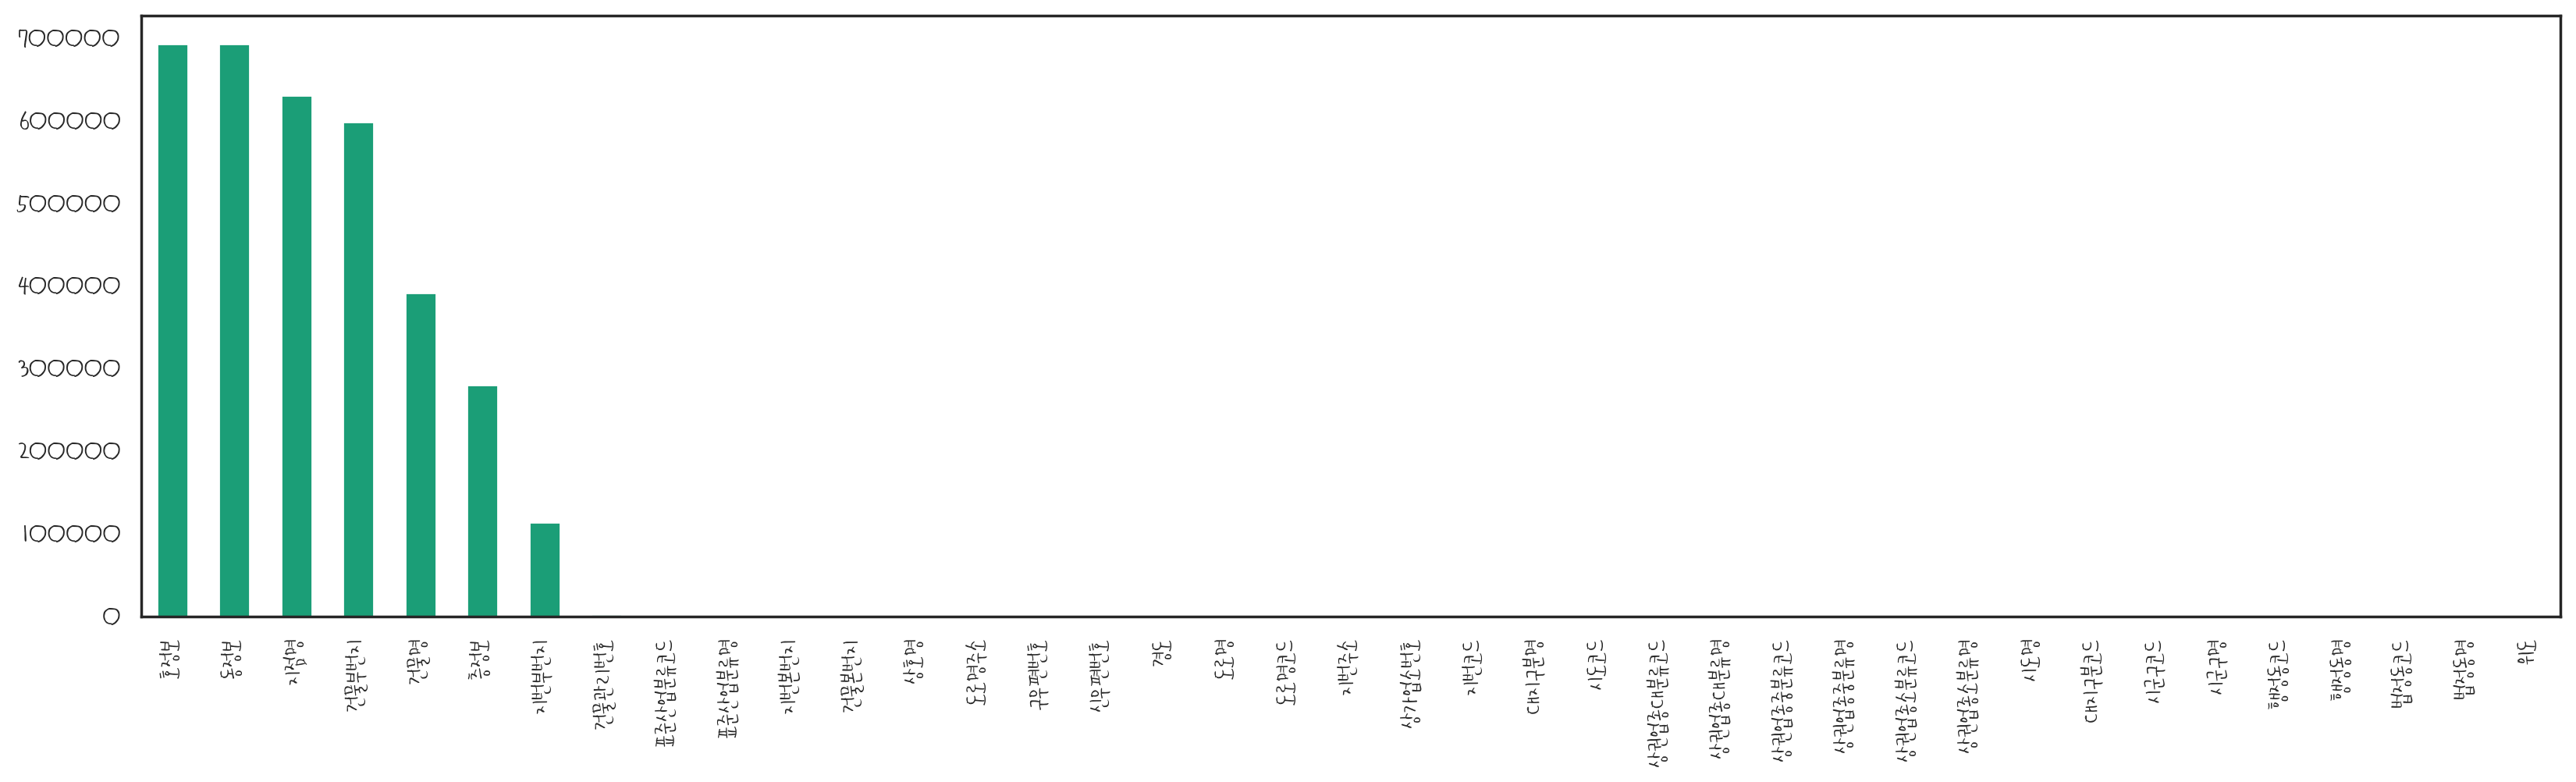

In [65]:
missing_cnt_sorted.plot(kind='bar', figsize=(20,5))

<Axes: >

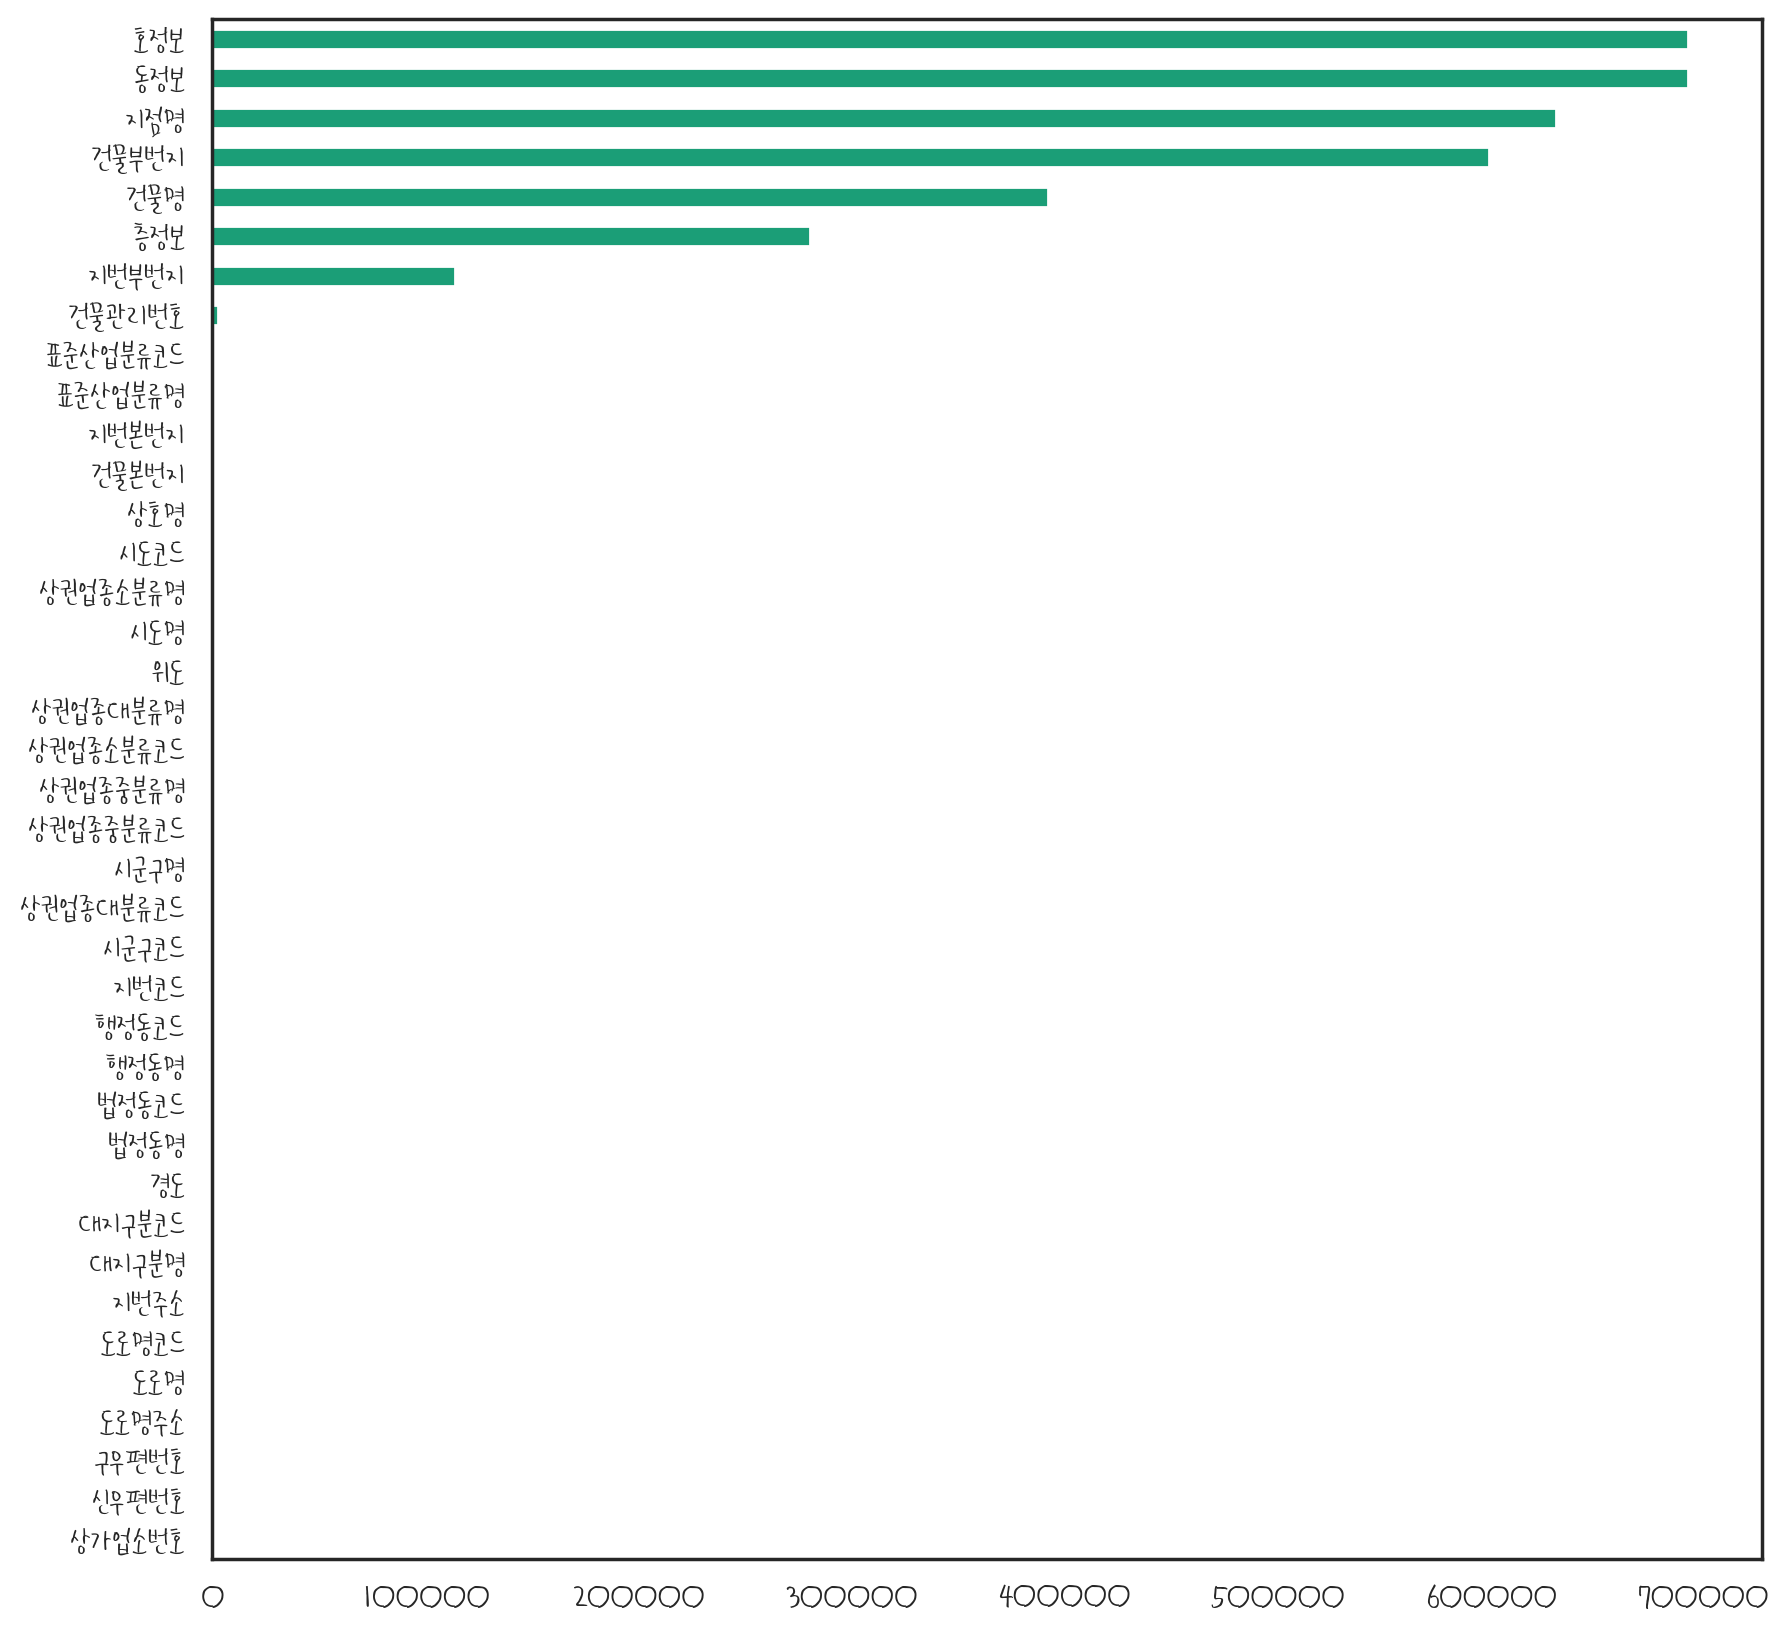

In [69]:
missing_cnt.sort_values().plot(kind='barh', figsize=(10,10))

## ④ 결측치가 없는 컬럼을 제외하고 시각화(정렬전 bar plot, barh plot, 정렬 후 bar plot, barh plot).

In [72]:
only_missing_cnt = missing_cnt[missing_cnt!=0]    

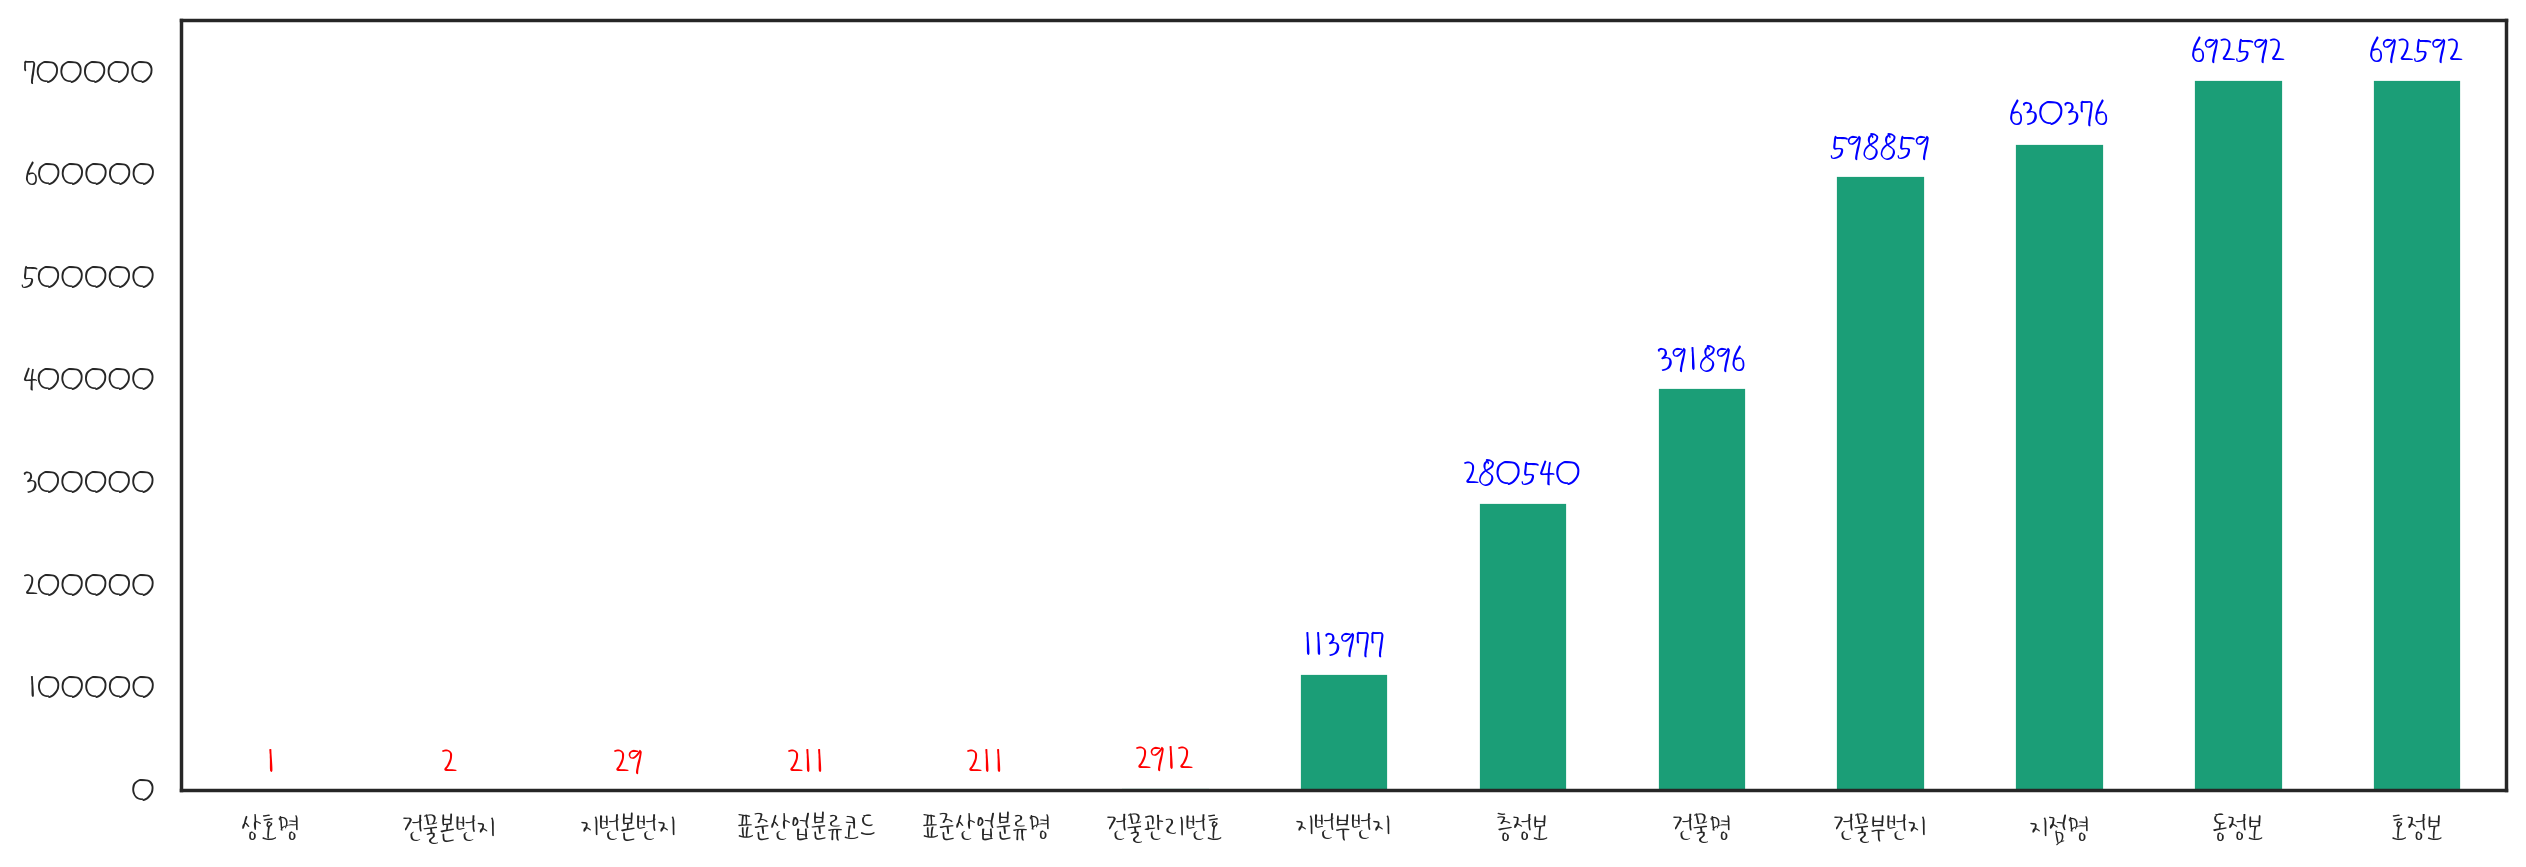

In [94]:
ax = only_missing_cnt.sort_values().plot(kind='bar', rot=0, figsize=(15,5), ylim=[0,750000])
plt.ylabel

labels = ax.bar_label(ax.containers[0], fmt="%.0f", padding=3, fontsize=12)

for bar, label in zip(ax.containers[0], labels):
    if bar.get_height() < 100000:
        label.set_color("red")
    else:
        label.set_color("blue")

plt.show()

In [84]:
result = only_missing_cnt.to_frame()
result.columns = ['결측치 개수']
result.head()

,결측치 개수
상호명,1
지점명,630376
표준산업분류코드,211
표준산업분류명,211
지번본번지,29


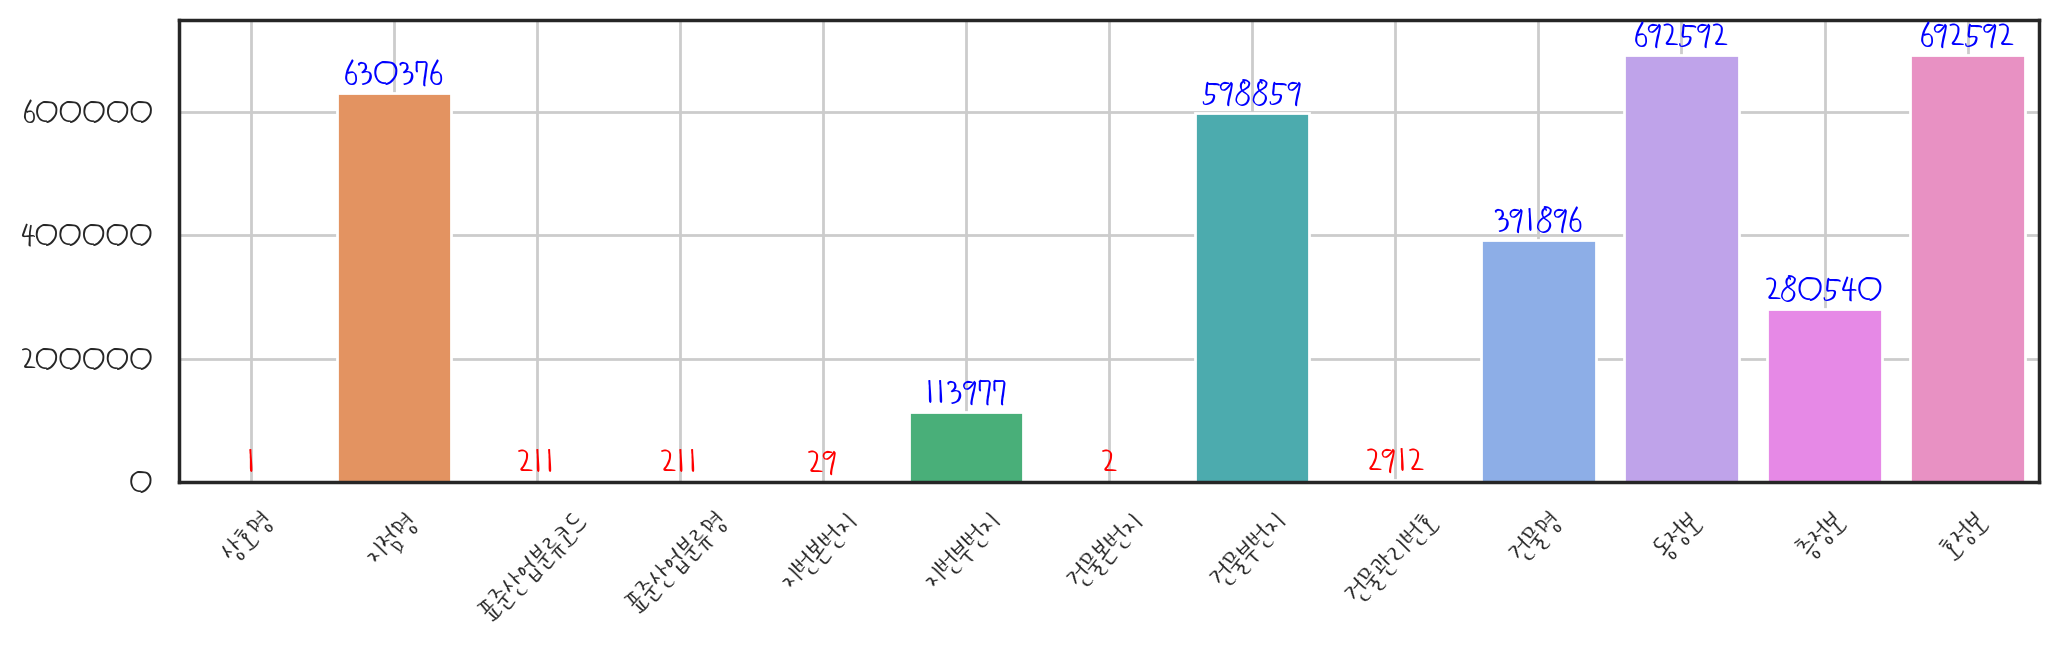

In [93]:
sns.barplot(x=only_missing_cnt.index, y=only_missing_cnt)

for i, v in enumerate(only_missing_cnt):
    if v>100000:
        plt.text(i, v, round(v), va='bottom', ha='center', size = 12, color='b')
    else:
        plt.text(i, v, round(v), va='bottom', ha='center', size = 12, color='r')

plt.xticks(rotation=45)        
plt.ylim(0,750000)
plt.grid('y')
plt.show()

## ⑤ missingno 라이브러리로 결측치 시각화
* [ResidentMario/missingno: Missing data visualization module for Python](https://github.com/ResidentMario/missingno)

* 위의 사이트를 열어 사용법 확인
`pip install missingno`

<Axes: >

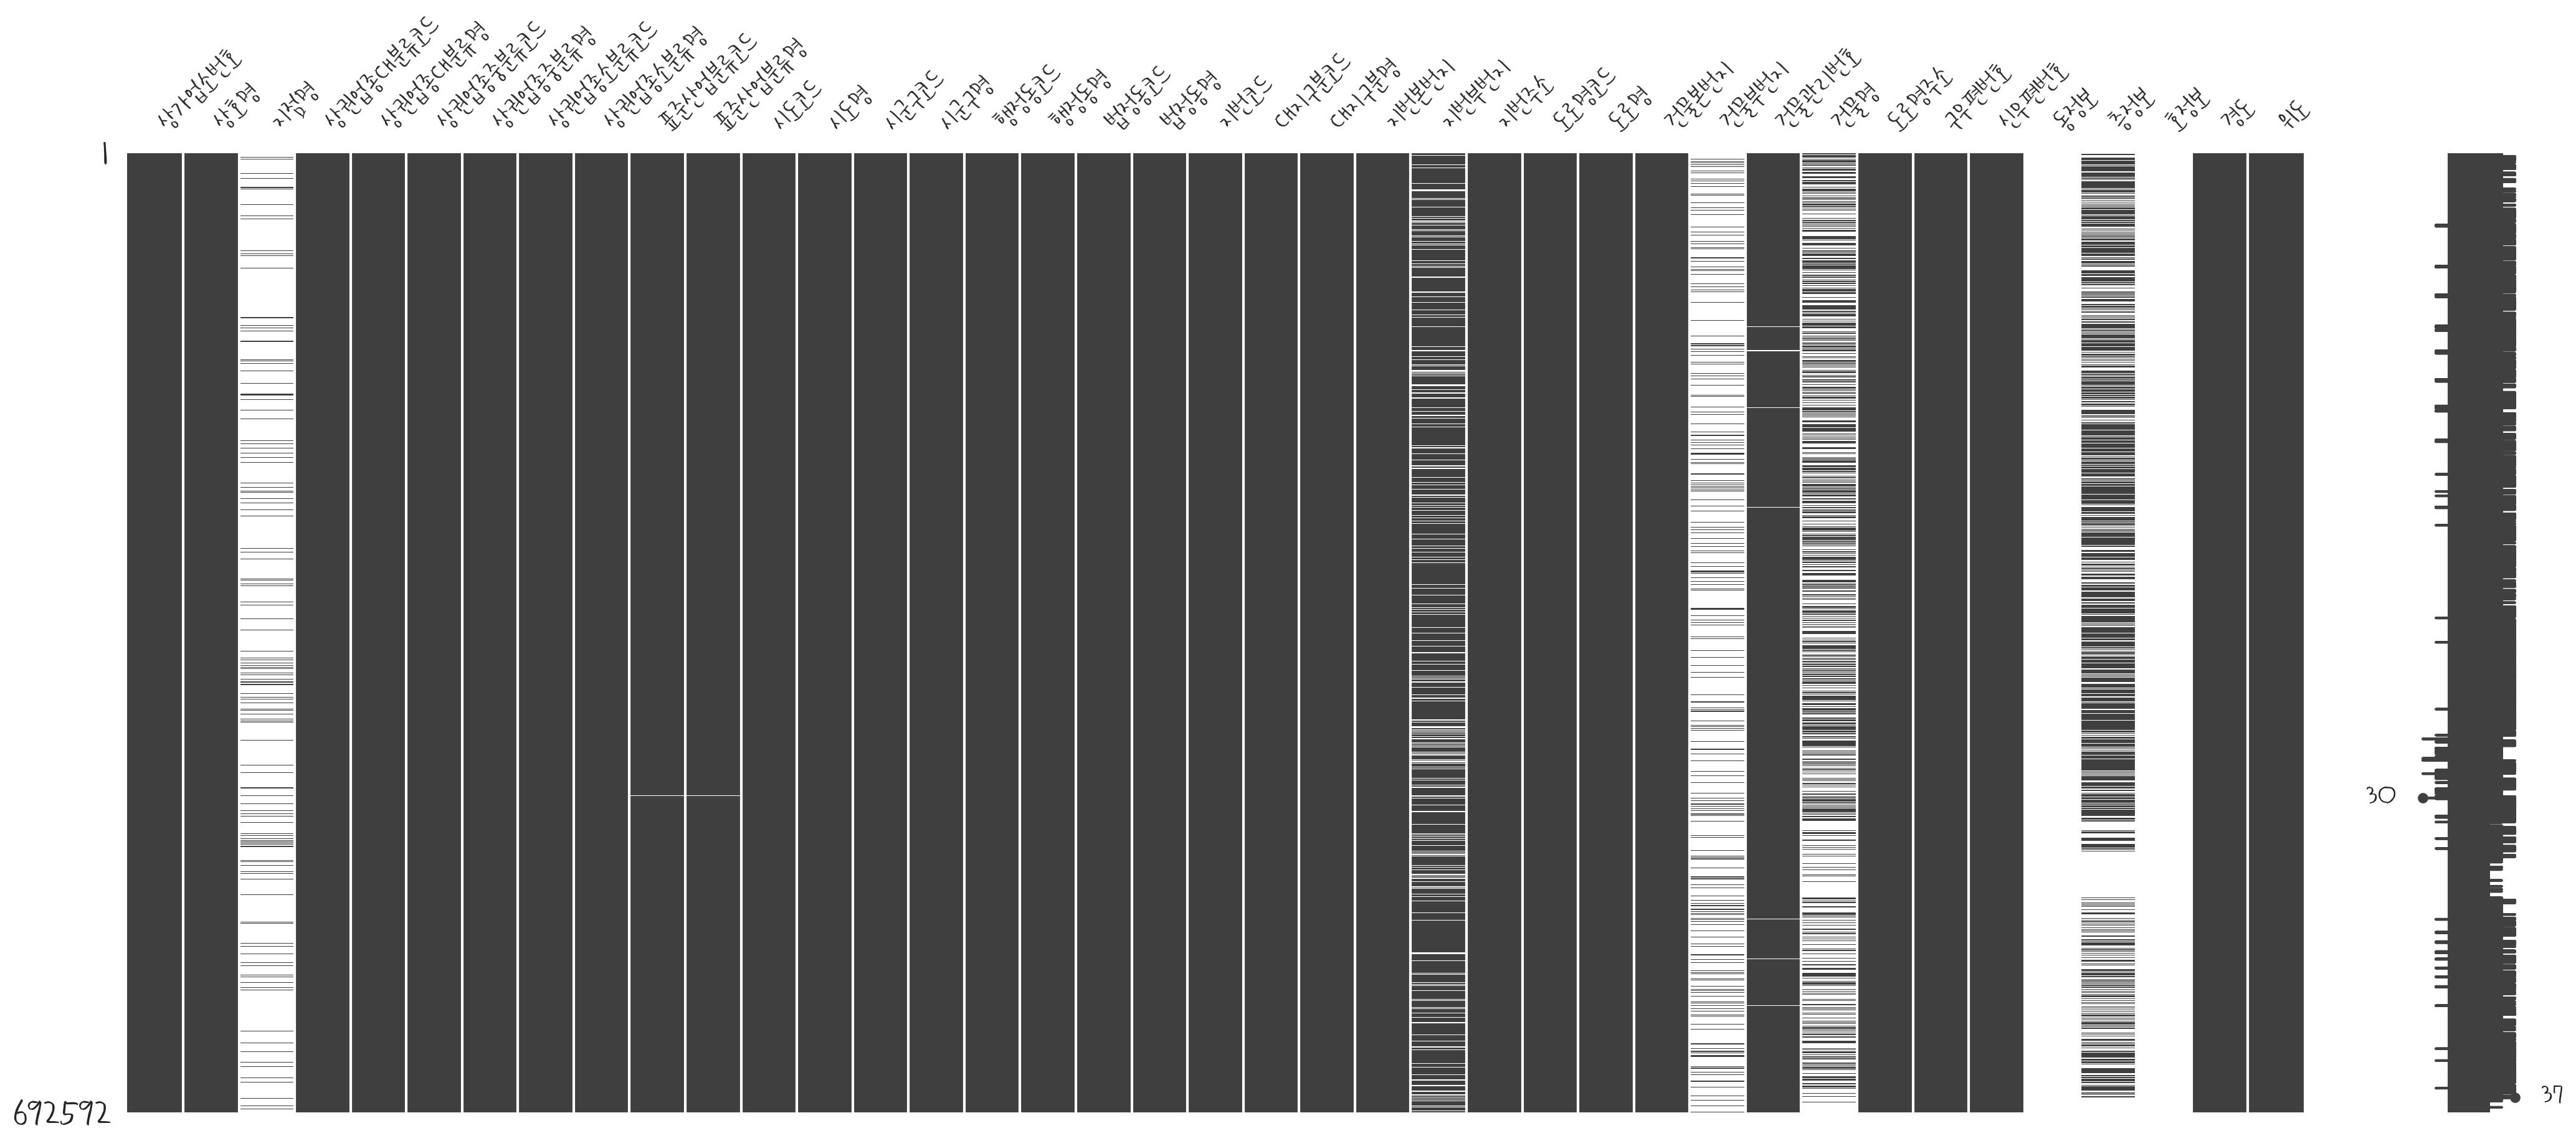

In [97]:
import missingno as msno

# 데이터 : 검은색, 결측치 : 흰색 표현
msno.matrix(df)

<Axes: >

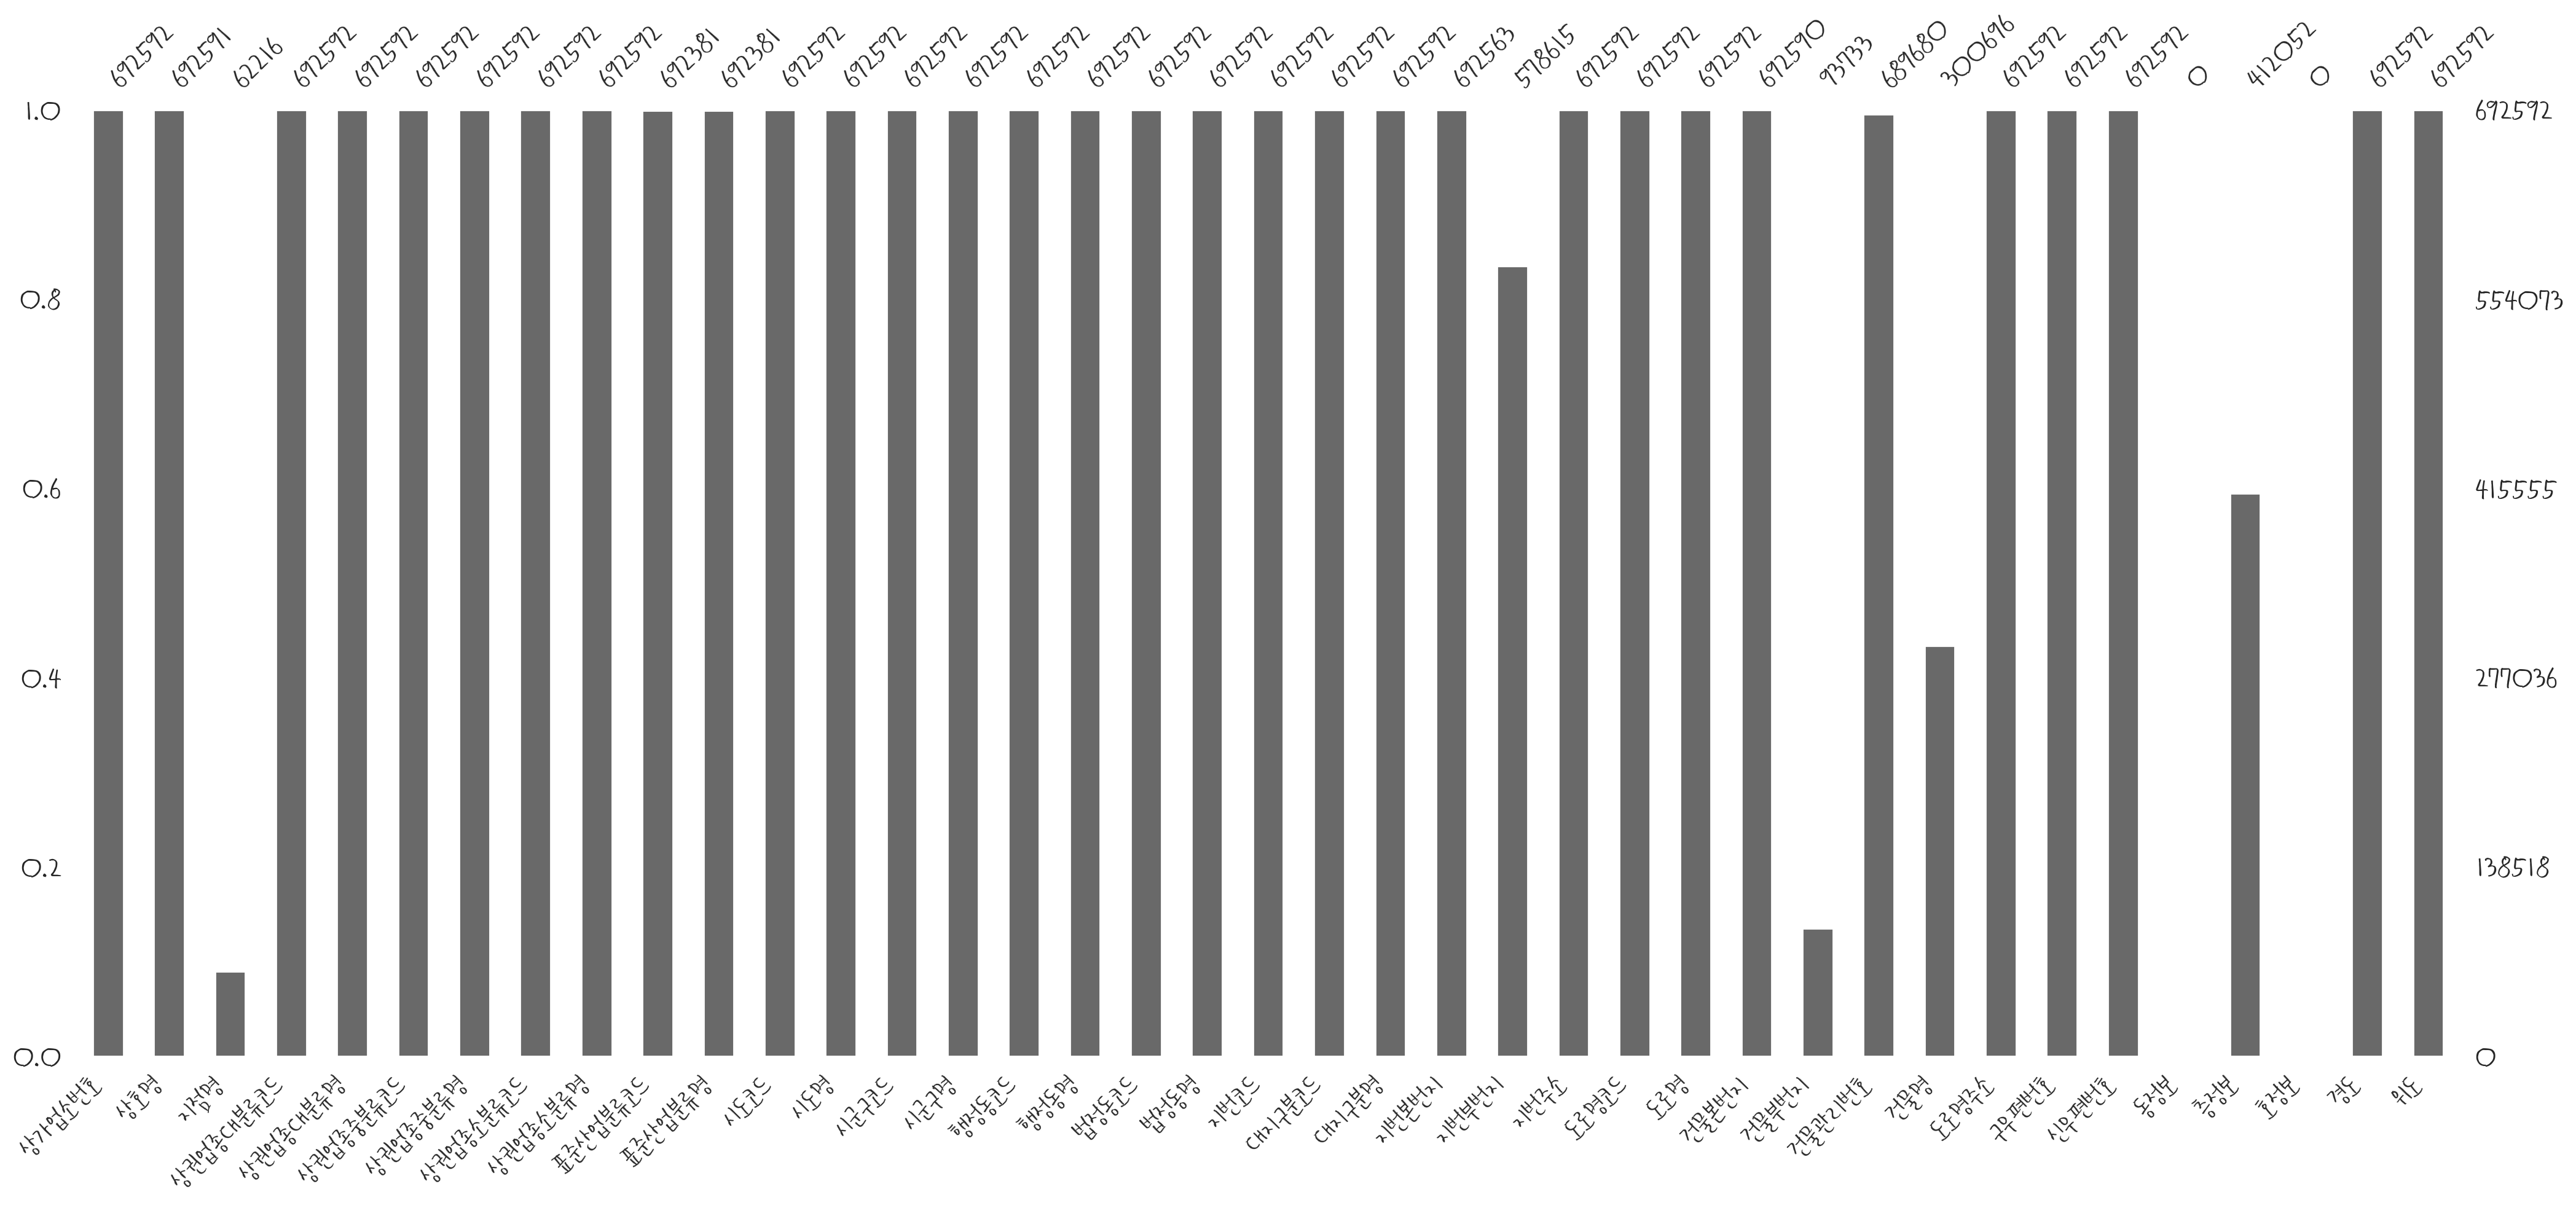

In [98]:
# 결측치가 아닌 데이터 개수
msno.bar(df)

# 4. 사용하지 않을 컬럼 제거
## ①결측치가 너무 많은 컬럼은 제거. (결측치 개수 상위 7개 컬럼 제거)

In [100]:
# 결측치 개수 상위 7개 컬럼 
not_use = df.isnull().sum().sort_values(ascending=False).head(7)

In [103]:
# 결측치 비율
round(not_use / df.shape[0] * 100, 2)

호정보      100.00
동정보      100.00
지점명       91.02
건물부번지     86.47
건물명       56.58
층정보       40.51
지번부번지     16.46
dtype: float64

In [105]:
# 컬럼 삭제 전 - 메모리 용량 : 206.1+ MB / 컬럼 수 : 39
print('컬럼 제거 전 shape :', df.shape)
# 컬럼 삭제
df = df.drop(not_use.index, axis=1)
# 컬럼 삭제 후 - 메모리 용량 : 169.1+ MB / 컬럼 수 : 32
print('컬럼 제거 후 shape :', df.shape)

컬럼 제거 전 shape : (692592, 39)
컬럼 제거 후 shape : (692592, 32)


## ②	컬럼명에 “코드”나 “번호”가 있는 컬럼 제거

In [123]:
cols = df.columns
drop_cols = df[cols[cols.str.contains('코드|번호') == 1]]

**※ 시리즈에 문자함수를 쓰기 위해 참조 :**
https://pandas.pydata.org/pandas-docs/stable/reference/series.html#string-handling

In [125]:
df.drop(drop_cols, axis=1, inplace=True)
# 컬럼 삭제 후 - 메모리 용량 : 89.8+ MB / 컬럼 수 : 17
print('컬럼 제거 후 shape :', df.shape)

컬럼 제거 후 shape : (692592, 17)


# ※ df 파일i/o

In [127]:
df.to_csv(r'C:\ai\downloads\shareData\상가정보\서울부산상가정보백업.csv', index=False)

In [128]:
df.to_csv(r'C:\ai\downloads\shareData\상가정보\서울부산상가정보백업.zip', index=False,  compression='infer')

In [ ]:
df = pd.read_csv(r"C:\ai\downloads\shareData\상가정보\서울부산상가정보백업.csv", low_memory=False)

# 5. df  값 호출하기(loc함수, iloc함수 등)
## ① 상호명 필드 호출


In [132]:
df['상호명']

0              참편한공인중개사사무소
1                  60계치킨암사
2                   성심인력공사
3                      칸토빈
4                  까치노래연습장
                ...       
692587        사회적협동조합 희망드림
692588                제주식품
692589                신천횟집
692590    주식회사  스타라이팅 일광지점
692591             이한나탁구클럽
Name: 상호명, Length: 692592, dtype: object

In [151]:
df.loc[:,'상호명']

0              참편한공인중개사사무소
1                  60계치킨암사
2                   성심인력공사
3                      칸토빈
4                  까치노래연습장
                ...       
692587        사회적협동조합 희망드림
692588                제주식품
692589                신천횟집
692590    주식회사  스타라이팅 일광지점
692591             이한나탁구클럽
Name: 상호명, Length: 692592, dtype: object

In [154]:
df.iloc[:,0]

0              참편한공인중개사사무소
1                  60계치킨암사
2                   성심인력공사
3                      칸토빈
4                  까치노래연습장
                ...       
692587        사회적협동조합 희망드림
692588                제주식품
692589                신천횟집
692590    주식회사  스타라이팅 일광지점
692591             이한나탁구클럽
Name: 상호명, Length: 692592, dtype: object

## ② 상호명 필드의 종류별 데이터 수(df.상호명.value_counts()이용)

In [135]:
df['상호명'].unique()

array(['참편한공인중개사사무소', '60계치킨암사', '성심인력공사', ..., '제주식품', '신천횟집',
       '주식회사  스타라이팅 일광지점'], dtype=object)

In [141]:
df.groupby('상호명')['경도'].count().sort_values(ascending=False).head()

상호명
업소명없음      793
컴퓨터수리      497
입시·교과학원    288
입주청소       262
김밥천국       214
Name: 경도, dtype: int64

In [142]:
df['상호명'].value_counts()

업소명없음               793
컴퓨터수리               497
입시·교과학원             288
입주청소                262
김밥천국                214
                   ... 
손가네곰국수                1
대한어머니회서울시연합사          1
소월마인드풀요가              1
우림인쇄                  1
주식회사  스타라이팅 일광지점      1
Name: 상호명, Length: 535061, dtype: int64

## ③	“상호명”과 "도로명주소” 컬럼 호출

In [145]:
df[['상호명', '도로명주소']]

,상호명,도로명주소
0,참편한공인중개사사무소,서울특별시 서초구 방배로19길 25
1,60계치킨암사,서울특별시 강동구 상암로3길 8
2,성심인력공사,서울특별시 용산구 한강대로 385
3,칸토빈,서울특별시 강서구 방화동로 30
4,까치노래연습장,서울특별시 노원구 한글비석로23길 2
...,...,...
692587,사회적협동조합 희망드림,부산광역시 동구 조방로 14
692588,제주식품,부산광역시 남구 동명로152번길 93
692589,신천횟집,부산광역시 중구 자갈치해안로 52
692590,주식회사 스타라이팅 일광지점,부산광역시 기장군 일광읍 일광로 808


## ④ 0~2행 출력 (loc과 iloc을 이용)

In [146]:
df.loc[:2]

,상호명,상권업종대분류명,상권업종중분류명,상권업종소분류명,표준산업분류명,시도명,시군구명,행정동명,법정동명,대지구분명,지번본번지,지번주소,도로명,건물본번지,도로명주소,경도,위도
0,참편한공인중개사사무소,부동산,부동산 서비스,부동산 중개/대리업,부동산 중개 및 대리업,서울특별시,서초구,방배1동,방배동,대지,927.0,서울특별시 서초구 방배동 927-35,서울특별시 서초구 방배로19길,25.0,서울특별시 서초구 방배로19길 25,126.993691,37.484844
1,60계치킨암사,음식,기타 간이,치킨,치킨 전문점,서울특별시,강동구,암사2동,암사동,대지,502.0,서울특별시 강동구 암사동 502-4,서울특별시 강동구 상암로3길,8.0,서울특별시 강동구 상암로3길 8,127.126859,37.550810
2,성심인력공사,시설관리·임대,고용 알선,고용 알선업,고용 알선업,서울특별시,용산구,남영동,동자동,대지,43.0,서울특별시 용산구 동자동 43-59,서울특별시 용산구 한강대로,385.0,서울특별시 용산구 한강대로 385,126.972240,37.552803


In [148]:
df.iloc[:3]

,상호명,상권업종대분류명,상권업종중분류명,상권업종소분류명,표준산업분류명,시도명,시군구명,행정동명,법정동명,대지구분명,지번본번지,지번주소,도로명,건물본번지,도로명주소,경도,위도
0,참편한공인중개사사무소,부동산,부동산 서비스,부동산 중개/대리업,부동산 중개 및 대리업,서울특별시,서초구,방배1동,방배동,대지,927.0,서울특별시 서초구 방배동 927-35,서울특별시 서초구 방배로19길,25.0,서울특별시 서초구 방배로19길 25,126.993691,37.484844
1,60계치킨암사,음식,기타 간이,치킨,치킨 전문점,서울특별시,강동구,암사2동,암사동,대지,502.0,서울특별시 강동구 암사동 502-4,서울특별시 강동구 상암로3길,8.0,서울특별시 강동구 상암로3길 8,127.126859,37.550810
2,성심인력공사,시설관리·임대,고용 알선,고용 알선업,고용 알선업,서울특별시,용산구,남영동,동자동,대지,43.0,서울특별시 용산구 동자동 43-59,서울특별시 용산구 한강대로,385.0,서울특별시 용산구 한강대로 385,126.972240,37.552803


# 6. 기술 통계값 보기 

- [Descriptive statistics - Wikipedia](https://en.wikipedia.org/wiki/Descriptive_statistics)
- [Computations / descriptive stats](https://pandas.pydata.org/docs/reference/frame.html#computations-descriptive-stats)
- [표준 편차 - 위키백과, 우리 모두의 백과사전](https://ko.wikipedia.org/wiki/표준편차)
* describe() 사용 시 데이터 요약을 볼 수 있음 ; 기술통계량
    - 기본적으로 수치형 데이터를 요약
    - include, exclude 옵션으로 다른 데이터 타입의 요약 수치 출력
    - count, min, max, mean, median, 1사분위수, 3사분위수

### **개별 기술 통계값 구하기**

* [Computations / descriptive stats](https://pandas.pydata.org/docs/reference/frame.html#computations-descriptive-stats)
* count : 결측치를 제외한 값 갯수
* min, max: 최솟값, 최댓값
* argmin, argmax : 최솟값 인덱스, 최댓값 인덱스 반환
* quantile : 특정 사분위수에 해당하는 값을 반환 (0~1 사이)
    * 0.25 : 1사분위 수
    * 0.5 : 2사분위수 (quantile 기본 값)
    * 0.75 : 3사분위수
* sum : 수치 데이터의 합계
* mean : 평균
* median : 중앙값(중간값:데이터를 한 줄로 세웠을 때 가운데 위치하는 값, 중앙값이 짝수일 때는 가운데 2개 값의 평균을 구함)

* std, var : 표준편차, 분산을 계산
* cumsum : 맨 첫 번째 성분부터 각 성분까지의 누적합을 계산 (0 번째 부터 계속 더해짐)
* cumprod : 맨 첫번째 성분부터 각 성분까지의 누적곱을 계산 (1 번째 부터 계속 곱해짐)
* cov, corr() : 공분산, 상관계수
* skew : 왜도 (오른쪽으로 치우침= 왜도<0, 왼쪽으로 치우침=왜도>0)
* kurt : 첨도


## ①	df의 요약기술 통계량

In [155]:
# 수치형 데이터에 대한 기술통계량
df.describe()

,지번본번지,건물본번지,경도,위도
count,692563.000000,692590.000000,692592.000000,692592.000000
mean,484.421211,144.045545,127.457120,37.008934
std,518.267621,264.093185,0.867369,0.991261
min,1.000000,1.000000,126.767661,34.989747
25%,112.000000,19.000000,126.943926,37.474629
50%,337.000000,47.000000,127.034613,37.514822
75%,688.000000,152.000000,127.131254,37.560404
max,6435.000000,3646.000000,129.294072,37.692604


In [159]:
# object형 데이터에 대한 기술 통계량
df.describe(include='object')

,상호명,상권업종대분류명,상권업종중분류명,상권업종소분류명,표준산업분류명,시도명,시군구명,행정동명,법정동명,대지구분명,지번주소,도로명,도로명주소
count,692591,692592,692592,692592,692381,692592,692592,692592,692592,692592,692592,692592,692592
unique,535061,10,75,247,386,2,39,630,647,2,221186,18817,220936
top,업소명없음,음식,한식,백반/한정식,한식 일반 음식점업,서울특별시,강남구,역삼1동,서초동,대지,서울특별시 송파구 문정동 634,서울특별시 강남구 테헤란로,서울특별시 송파구 충민로 66
freq,793,190725,75607,39765,60780,537489,64239,13420,17901,691744,881,4248,1123


## ②	“지번본번지", "건물본번지” 컬럼의 데이터 개수와  dtype, 메모리 사용량을 확인

In [160]:
df[['지번본번지','건물본번지']].count()

지번본번지    692563
건물본번지    692590
dtype: int64

In [161]:
df[['지번본번지','건물본번지']].info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 692592 entries, 0 to 692591
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   지번본번지   692563 non-null  float64
 1   건물본번지   692590 non-null  float64
dtypes: float64(2)
memory usage: 10.6 MB


## ③	“위도", "경도” 컬럼의 요약 기술통계량

In [163]:
df[['위도', '경도']].describe()

,위도,경도
count,692592.000000,692592.000000
mean,37.008934,127.457120
std,0.991261,0.867369
min,34.989747,126.767661
25%,37.474629,126.943926
50%,37.514822,127.034613
75%,37.560404,127.131254
max,37.692604,129.294072


# 7.단별량 수치형 변수 시각화
## ① 위도의 빈도표를 시각화 : plot.hist, hist, sns.displot, sns.histplot

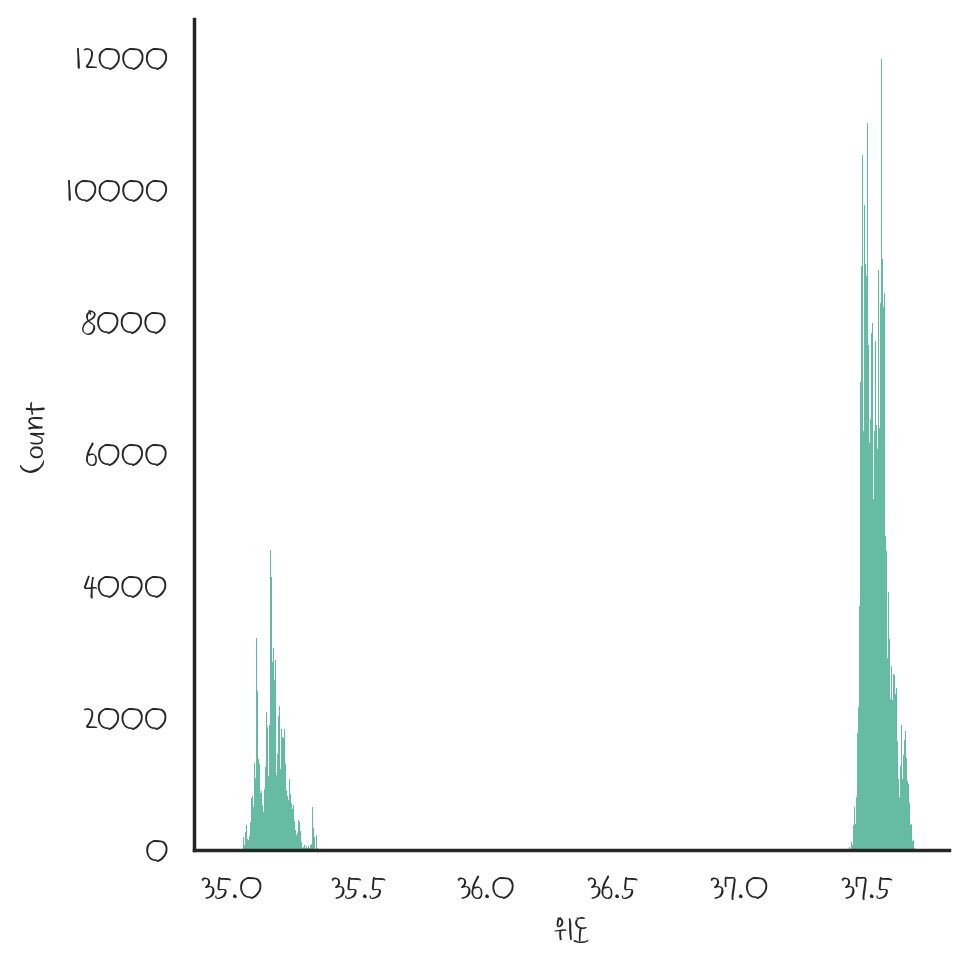

In [175]:
sns.displot(data=df, x='위도')

<Axes: ylabel='Frequency'>

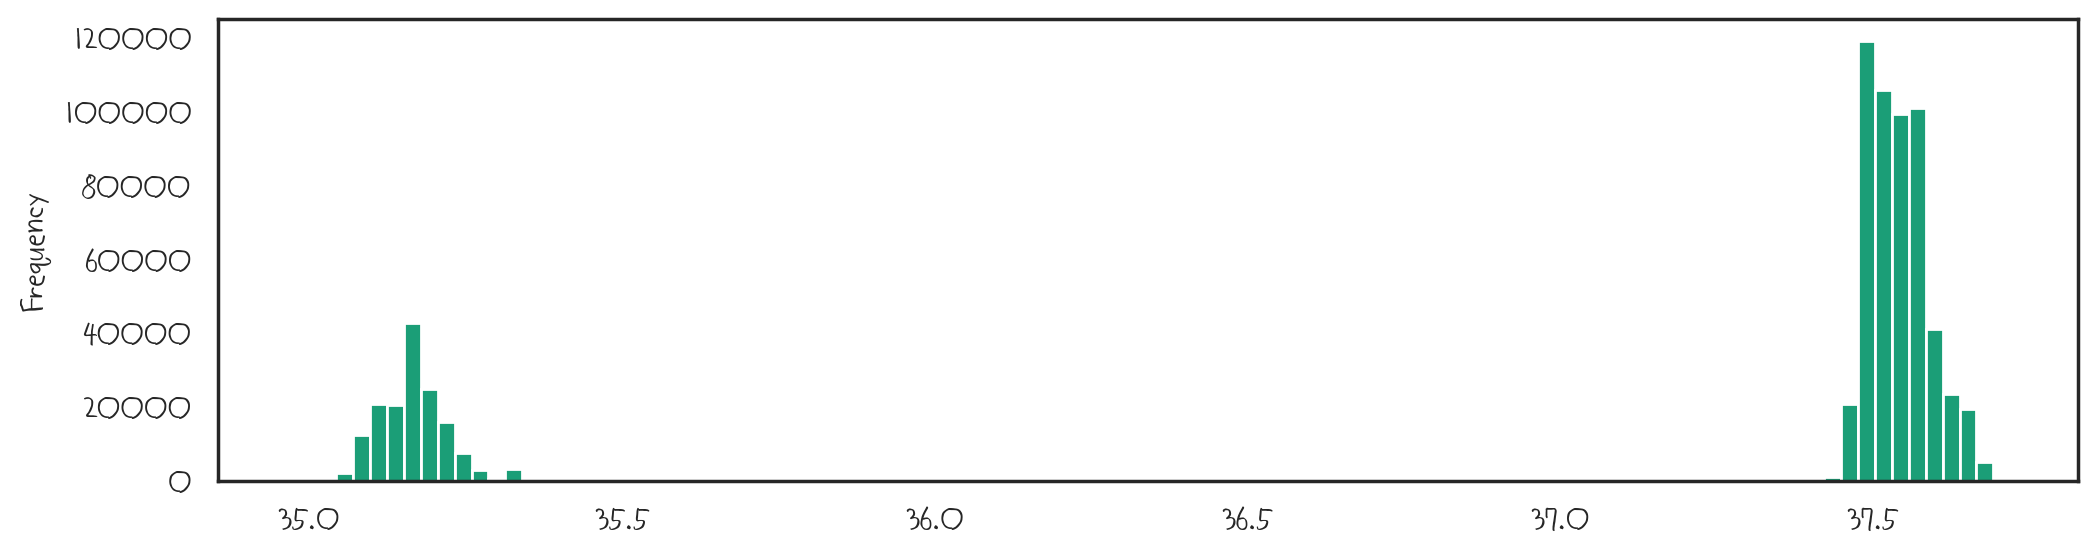

In [167]:
df['위도'].plot(kind='hist', bins=100)

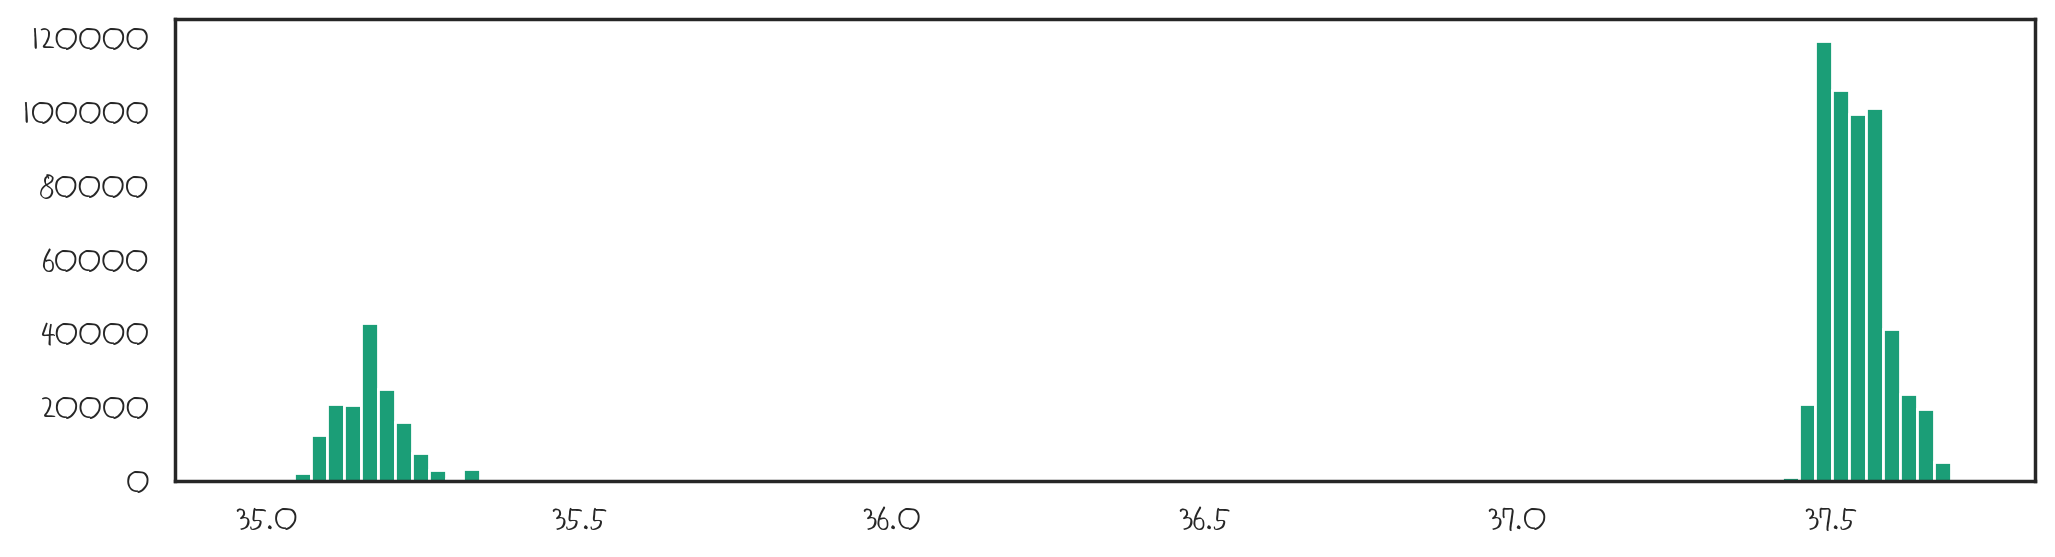

In [173]:
plt.hist(df['위도'], bins=100)
plt.show()

Text(37.2, 10000, '중위수')

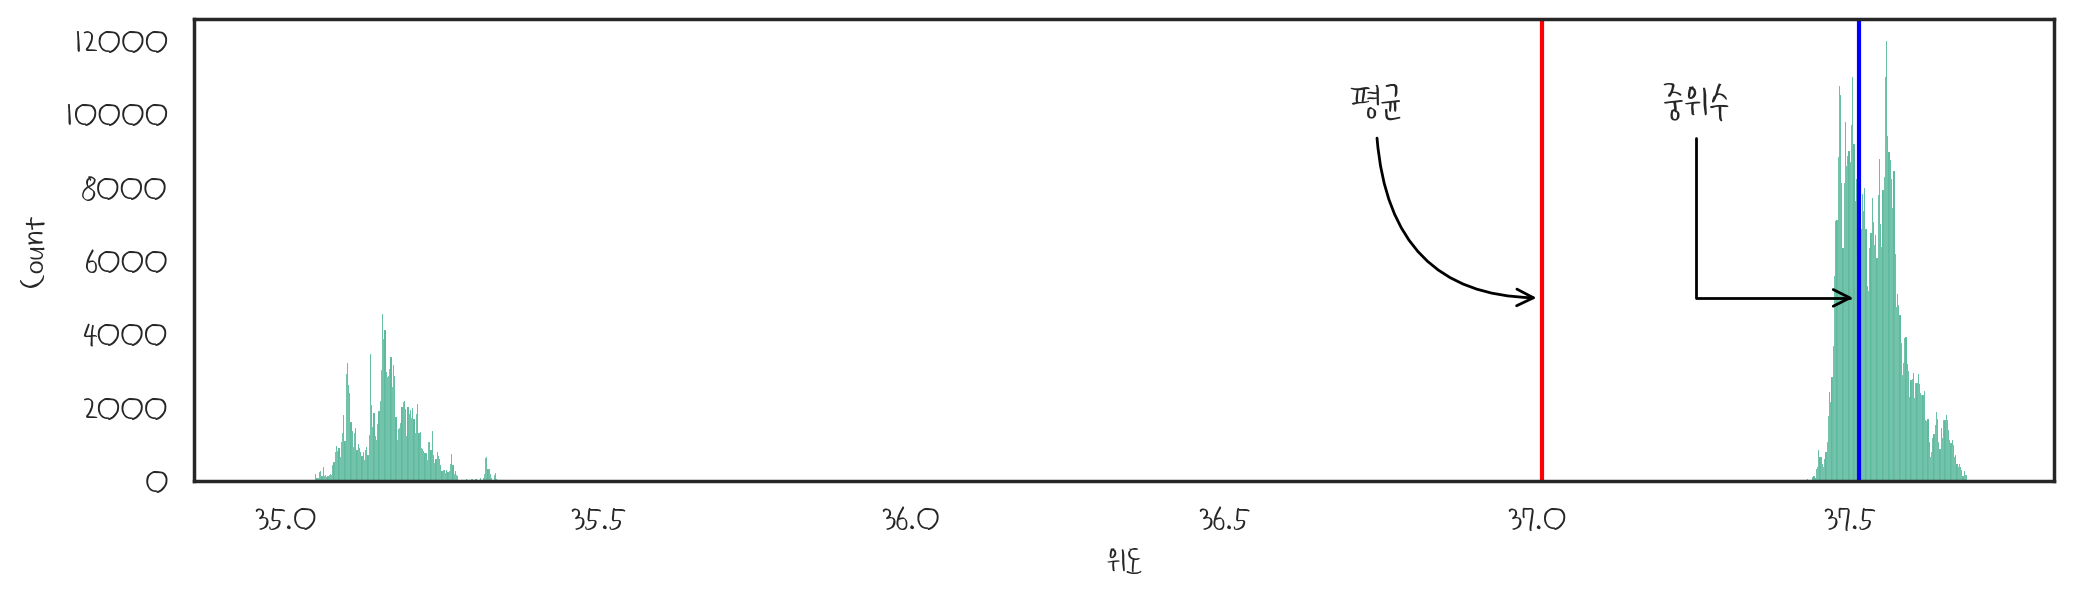

In [194]:
sns.histplot(data=df, x='위도')
plt.axvline(df['위도'].mean(), color='r')
plt.annotate('평균', xytext=(36.7, 10000), 
             xy=(df['위도'].mean(),5000),
             arrowprops = dict(arrowstyle='->',
             connectionstyle='angle3',
             color='k'),
             fontsize=15)
plt.axvline(df['위도'].median(), color='b')
plt.annotate('중위수', xytext=(37.2, 10000), 
             xy=(df['위도'].median(),5000),
             arrowprops = dict(arrowstyle='->',
             connectionstyle='angle',
             color='k'),
             fontsize=15)

## ② 경도의 빈도표를 시각화 : plot.hist, hist, sns.displot, sns.histplot

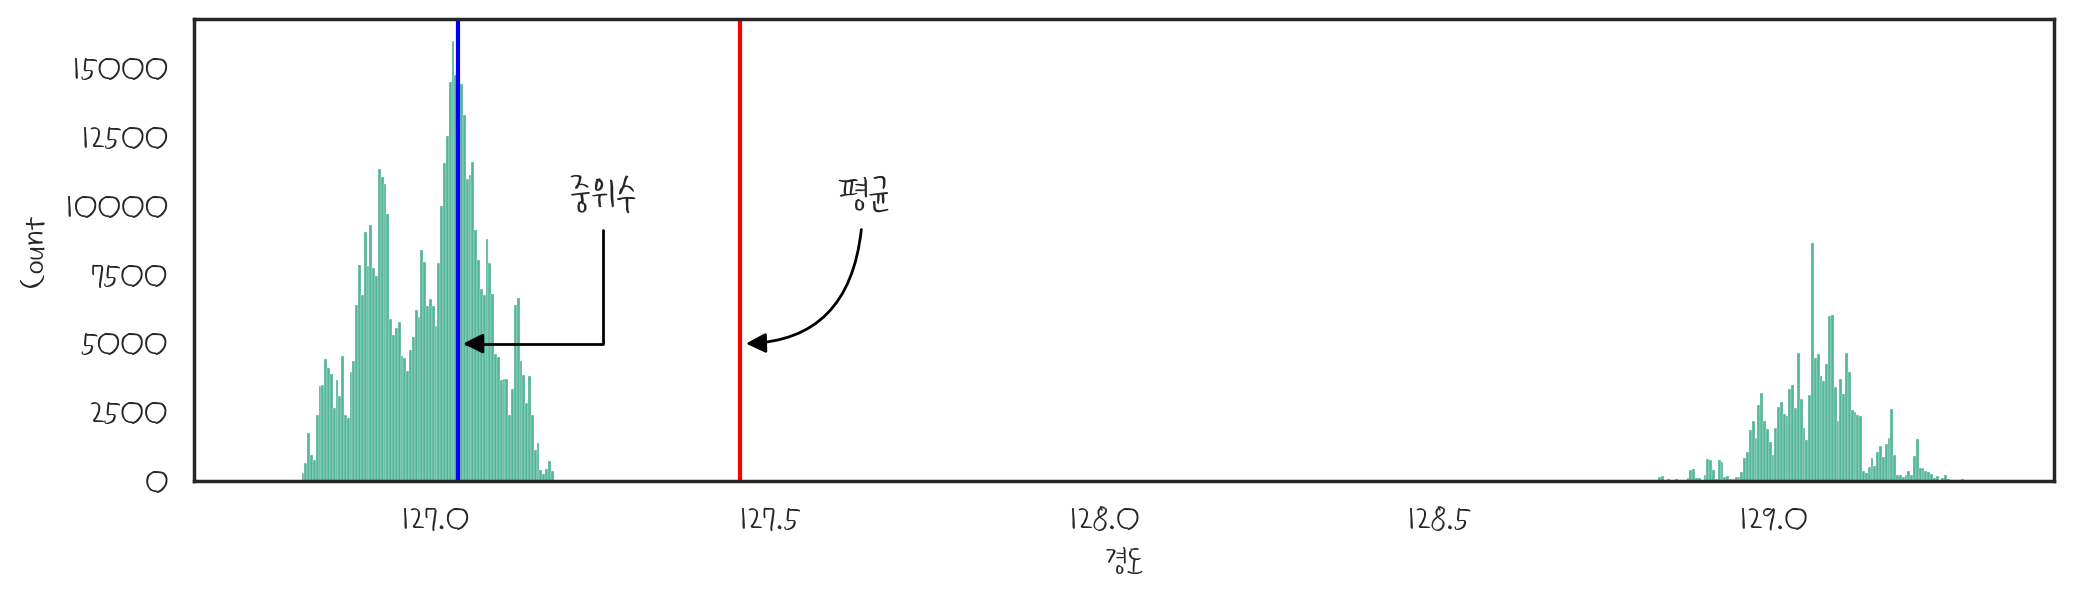

In [209]:
sns.histplot(data=df, x='경도')
plt.axvline(df['경도'].mean(), color='r')
plt.annotate('평균', xytext=(127.6, 10000), 
             xy=(df['경도'].mean(),5000),
             arrowprops = dict(arrowstyle='-|>',
             connectionstyle='angle3',
             color='k'),
             fontsize=15)
plt.axvline(df['경도'].median(), color='b')
plt.annotate('중위수', xytext=(127.2, 10000), 
             xy=(df['경도'].median(),5000),
             arrowprops = dict(arrowstyle='-|>',
             connectionstyle='angle',
             color='k'),
             fontsize=15)
plt.show()

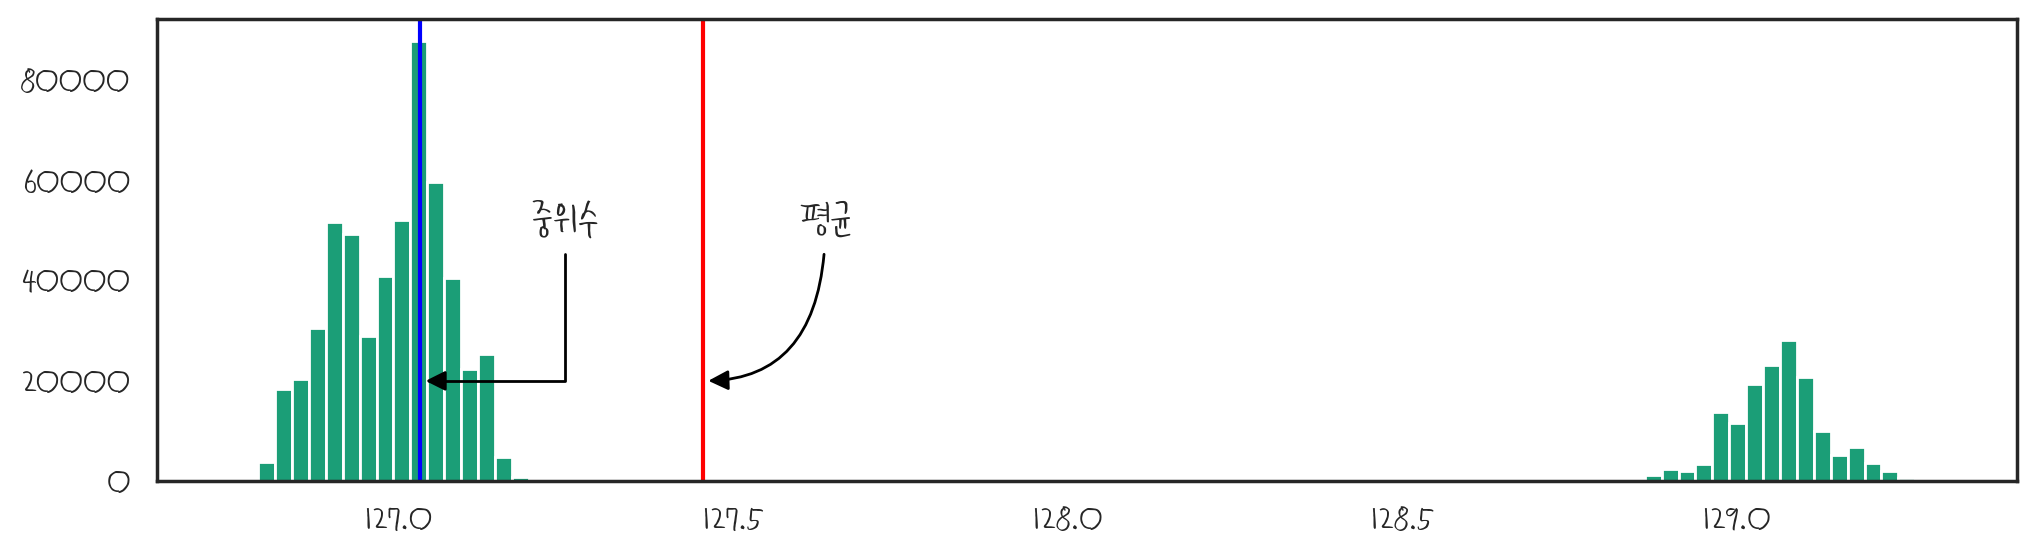

In [213]:
plt.hist(df['경도'], bins=100)
plt.axvline(df['경도'].mean(), color='r')
plt.annotate('평균', xytext=(127.6, 50000), 
             xy=(df['경도'].mean(),20000),
             arrowprops = dict(arrowstyle='-|>',
             connectionstyle='angle3',
             color='k'),
             fontsize=15)
plt.axvline(df['경도'].median(), color='b')
plt.annotate('중위수', xytext=(127.2, 50000), 
             xy=(df['경도'].median(),20000),
             arrowprops = dict(arrowstyle='-|>',
             connectionstyle='angle',
             color='k'),
             fontsize=15)
plt.show()

In [215]:
df['위도'].skew()

-1.3201510434921953

In [217]:
df['위도'].kurt()

-0.2430367649268903

# 8. 상관계수
-  두 변수 간에 어떤 선형적 관계를 갖고 있는 지를 분석하는 방법
- [상관 분석 - 위키백과, 우리 모두의 백과사전M](https://ko.wikipedia.org/wiki/상관_분석) 

- 결과의 해석 : r 값은 X 와 Y 가 완전히 동일할 때 +1, 전혀 다르면 0, 반대방향으로 완전히 동일하면 –1 을 가진다. 결정계수(coefficient of determination)는 $r^2$로 계산하며 이것은 X 로부터 Y를 예측할 수 있는 정도를 의미한다.
- ([수학기호 사이트 참조](https://matplotlib.org/2.0.2/users/mathtext.html))

- 일반적으로
    * r이 -1.0과 -0.7 사이이면, 강한 음적 선형관계,
    * r이 -0.7과 -0.3 사이이면, 뚜렷한 음적 선형관계,
    * r이 -0.3과 -0.1 사이이면, 약한 음적 선형관계,
    * r이 -0.1과 +0.1 사이이면, 무시할 수 있는 선형관계,
    * r이 +0.1과 +0.3 사이이면, 약한 양적 선형관계,
    * r이 +0.3과 +0.7 사이이면, 뚜렷한 양적 선형관계,
    * r이 +0.7과 +1.0 사이이면, 강한 양적 선형관계로 해석한다.

<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/d/d4/Correlation_examples2.svg/1280px-Correlation_examples2.svg.png" width="600">

이미지 출처 : [위키백과](https://ko.wikipedia.org/wiki/상관_분석)


## ① 전체 숫자 컬럼끼리의 상관계수

In [245]:
corr = df.corr(numeric_only=True)

## ②	상관계수를 이용하여 heatmap 시각화
- 참조 http://seaborn.pydata.org/examples/many_pairwise_correlations.html 

<Axes: >

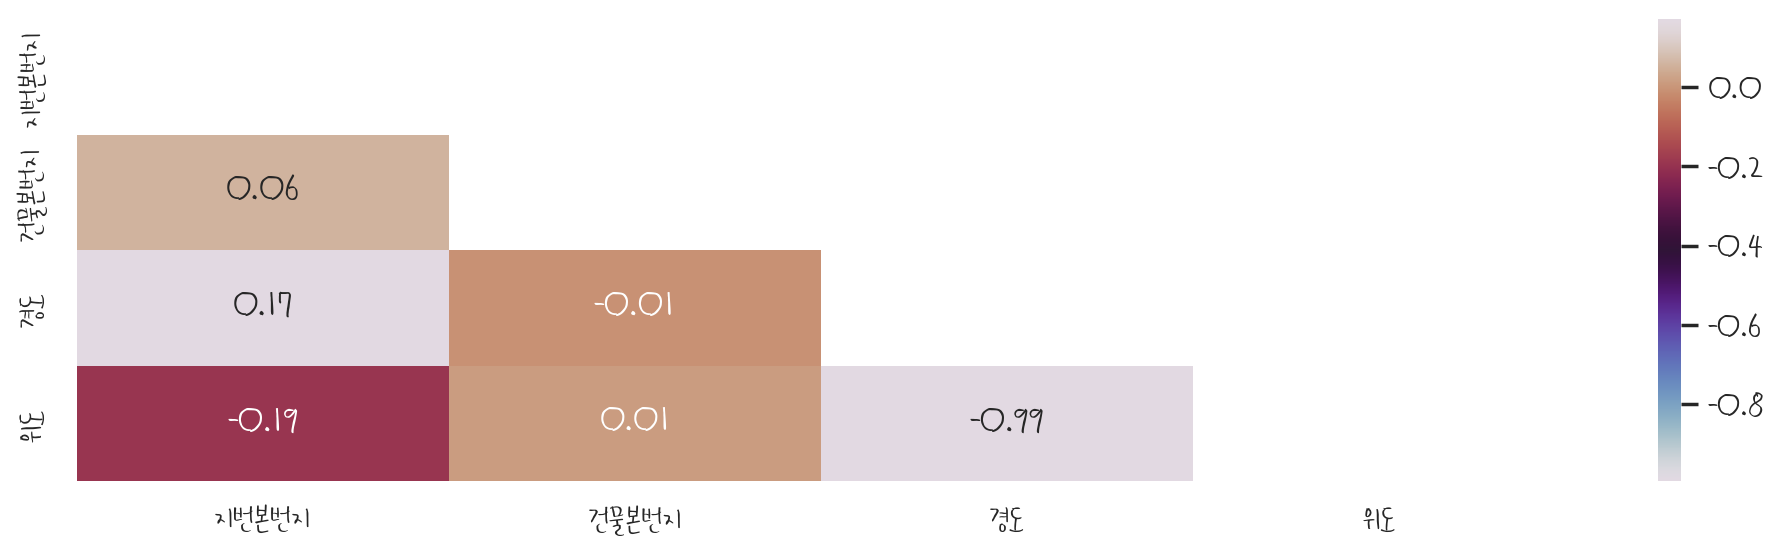

In [248]:
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='twilight')

<Axes: >

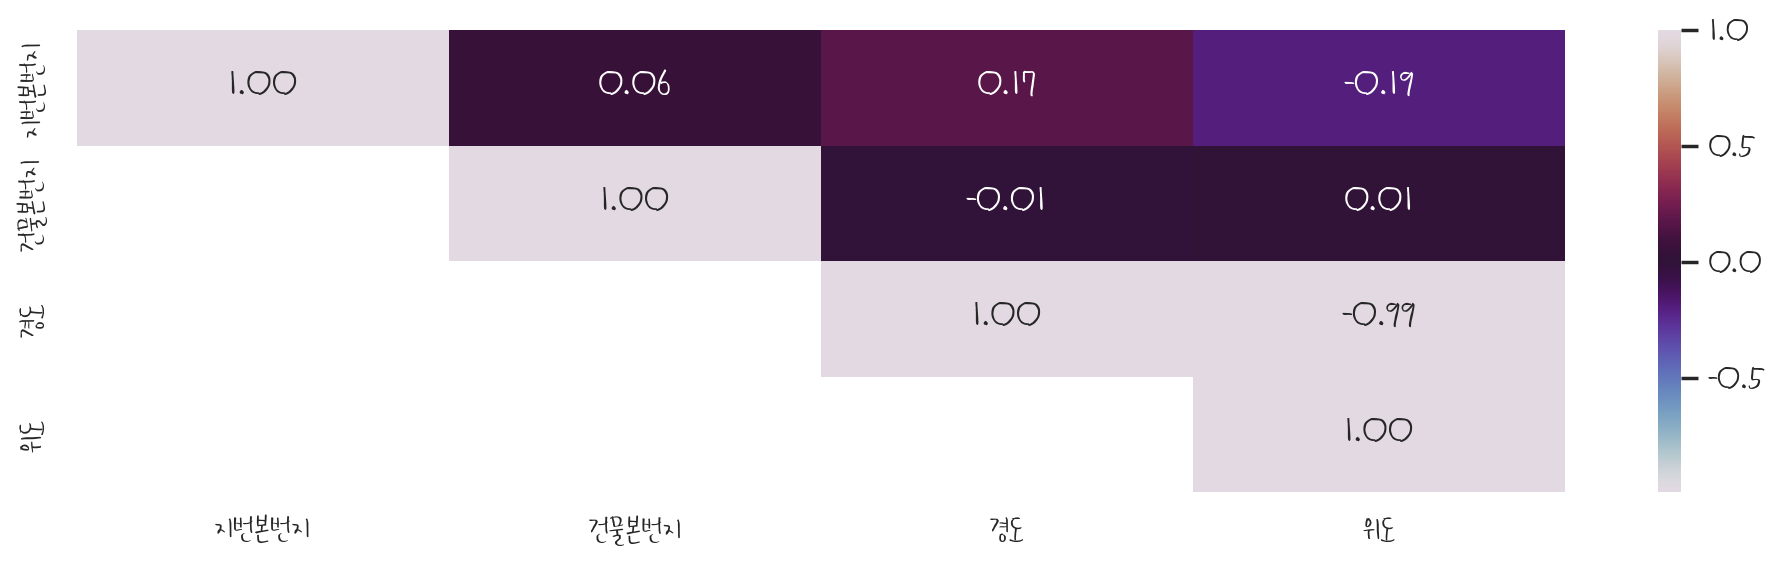

In [250]:
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=~mask, annot=True, fmt='.2f', cmap='twilight')

# 9.	경도와 위도 컬럼을 이용하여 산점도

[Anscombe’s quartet — seaborn 0.10.0 documentation](https://seaborn.pydata.org/examples/anscombes_quartet.html)

## ①	X축에는 경도, y축에는 위도 컬럼을 산점도로 시각화

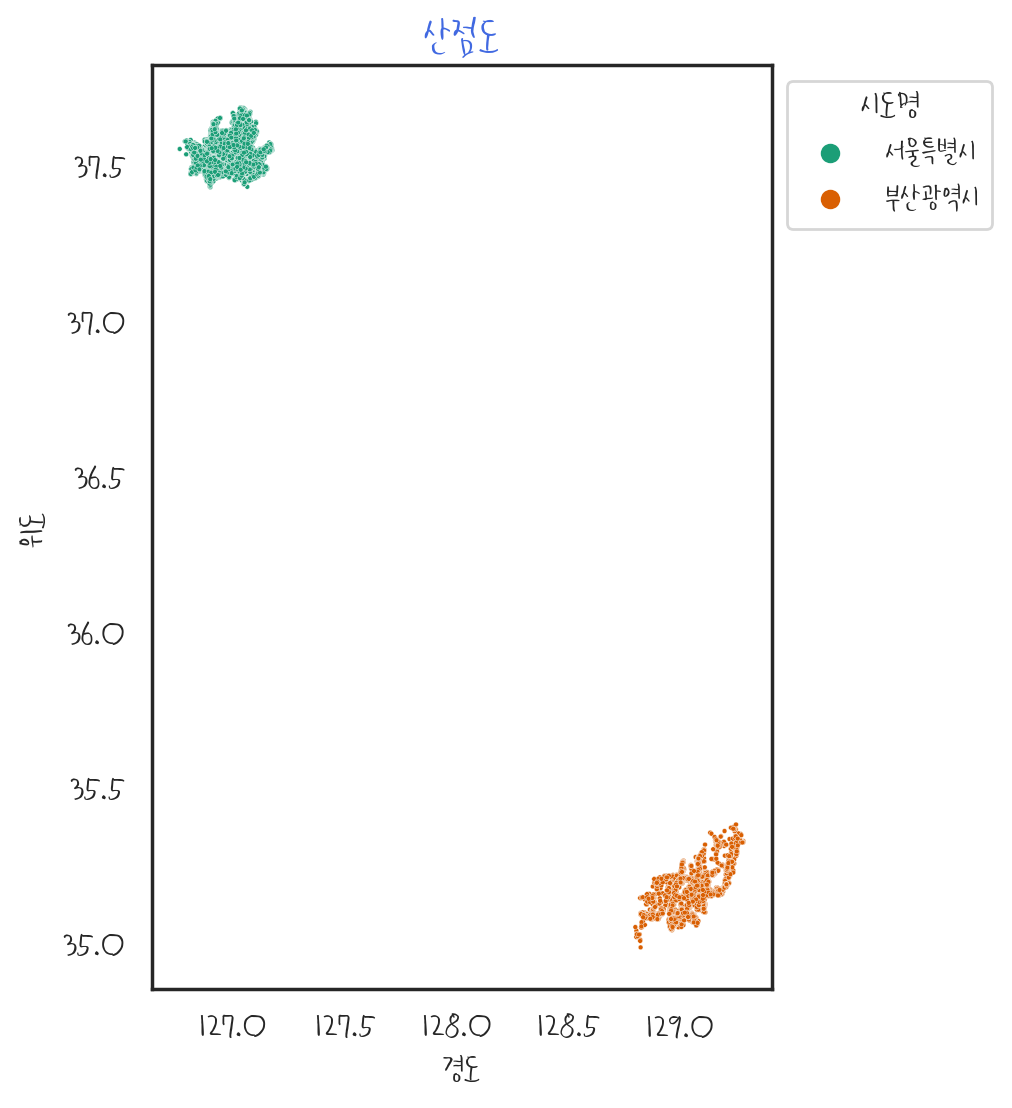

In [274]:
plt.figure(figsize=(4,6))
ax=sns.scatterplot(data=df.sample(frac=0.1), x='경도', y='위도', hue='시도명', s=3)
ax.set_title('산점도', color='royalblue', fontsize=15)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.show()

## ②	경도와 위도의 산점도를 “시도명” 컬럼별로 서브플롯으로 시각화

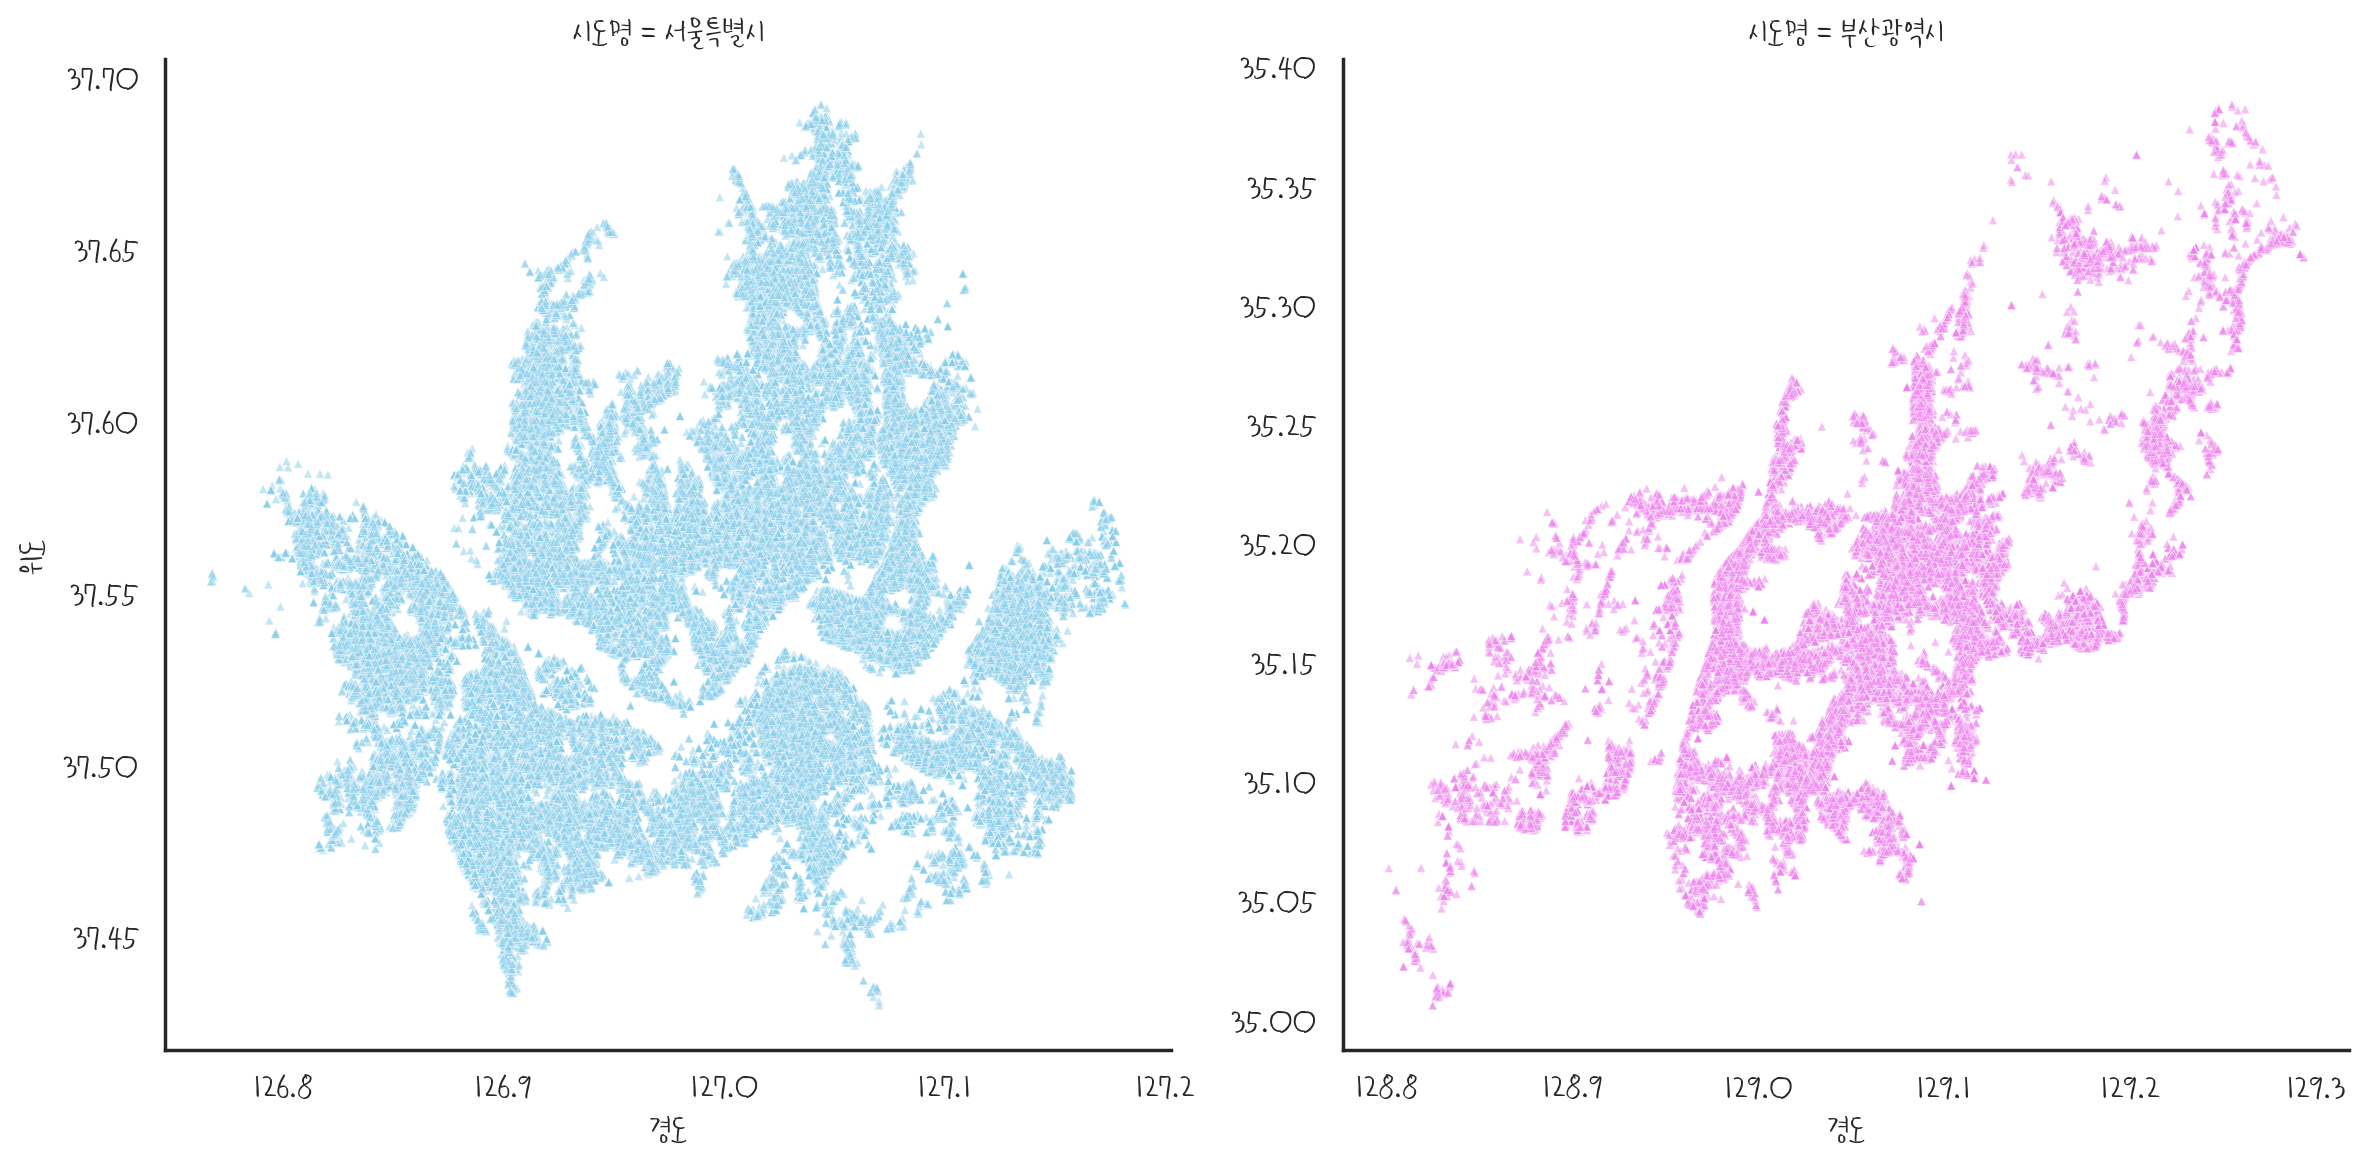

In [296]:
sns.relplot(kind='scatter', data=df.sample(frac=0.8), marker='^', x='경도', y='위도', hue='시도명', s=10, col='시도명',
            facet_kws={'sharex':False,'sharey':False}, height=6, aspect=1, legend=False, col_order=['서울특별시', '부산광역시'], alpha=0.5, palette=['skyblue','violet'])

plt.show()

## ③ 위의 1번에서 시각화된 산점도를 바탕으로 회귀선을 그린다.

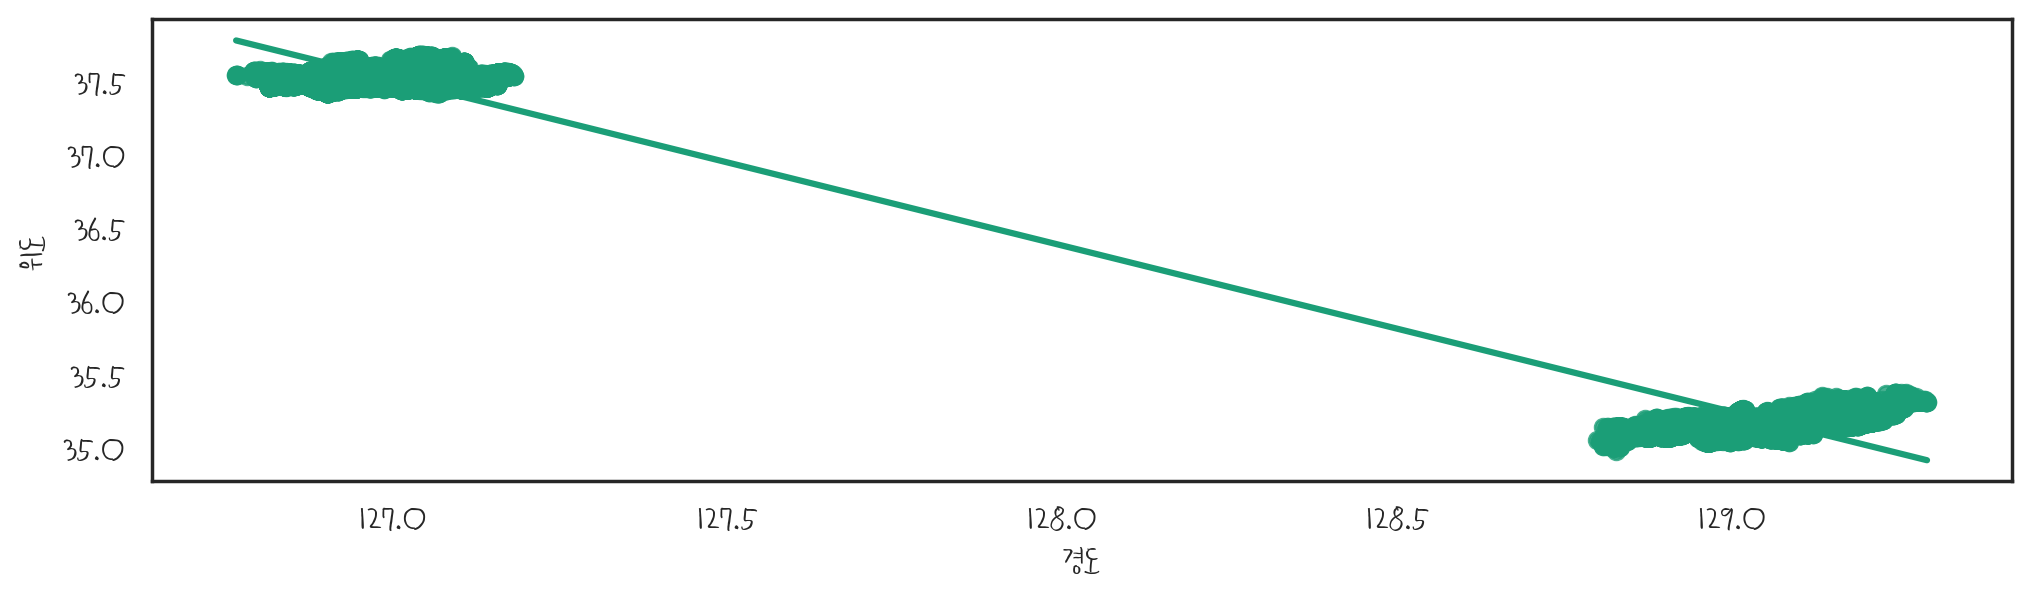

In [303]:
sns.regplot(data=df.sample(frac=0.5), x='경도', y='위도')

plt.show()

## ④ 위의 2번에서 시각화된 산점도를 바탕으로 회귀선을 서브 플롯으로 그린다.

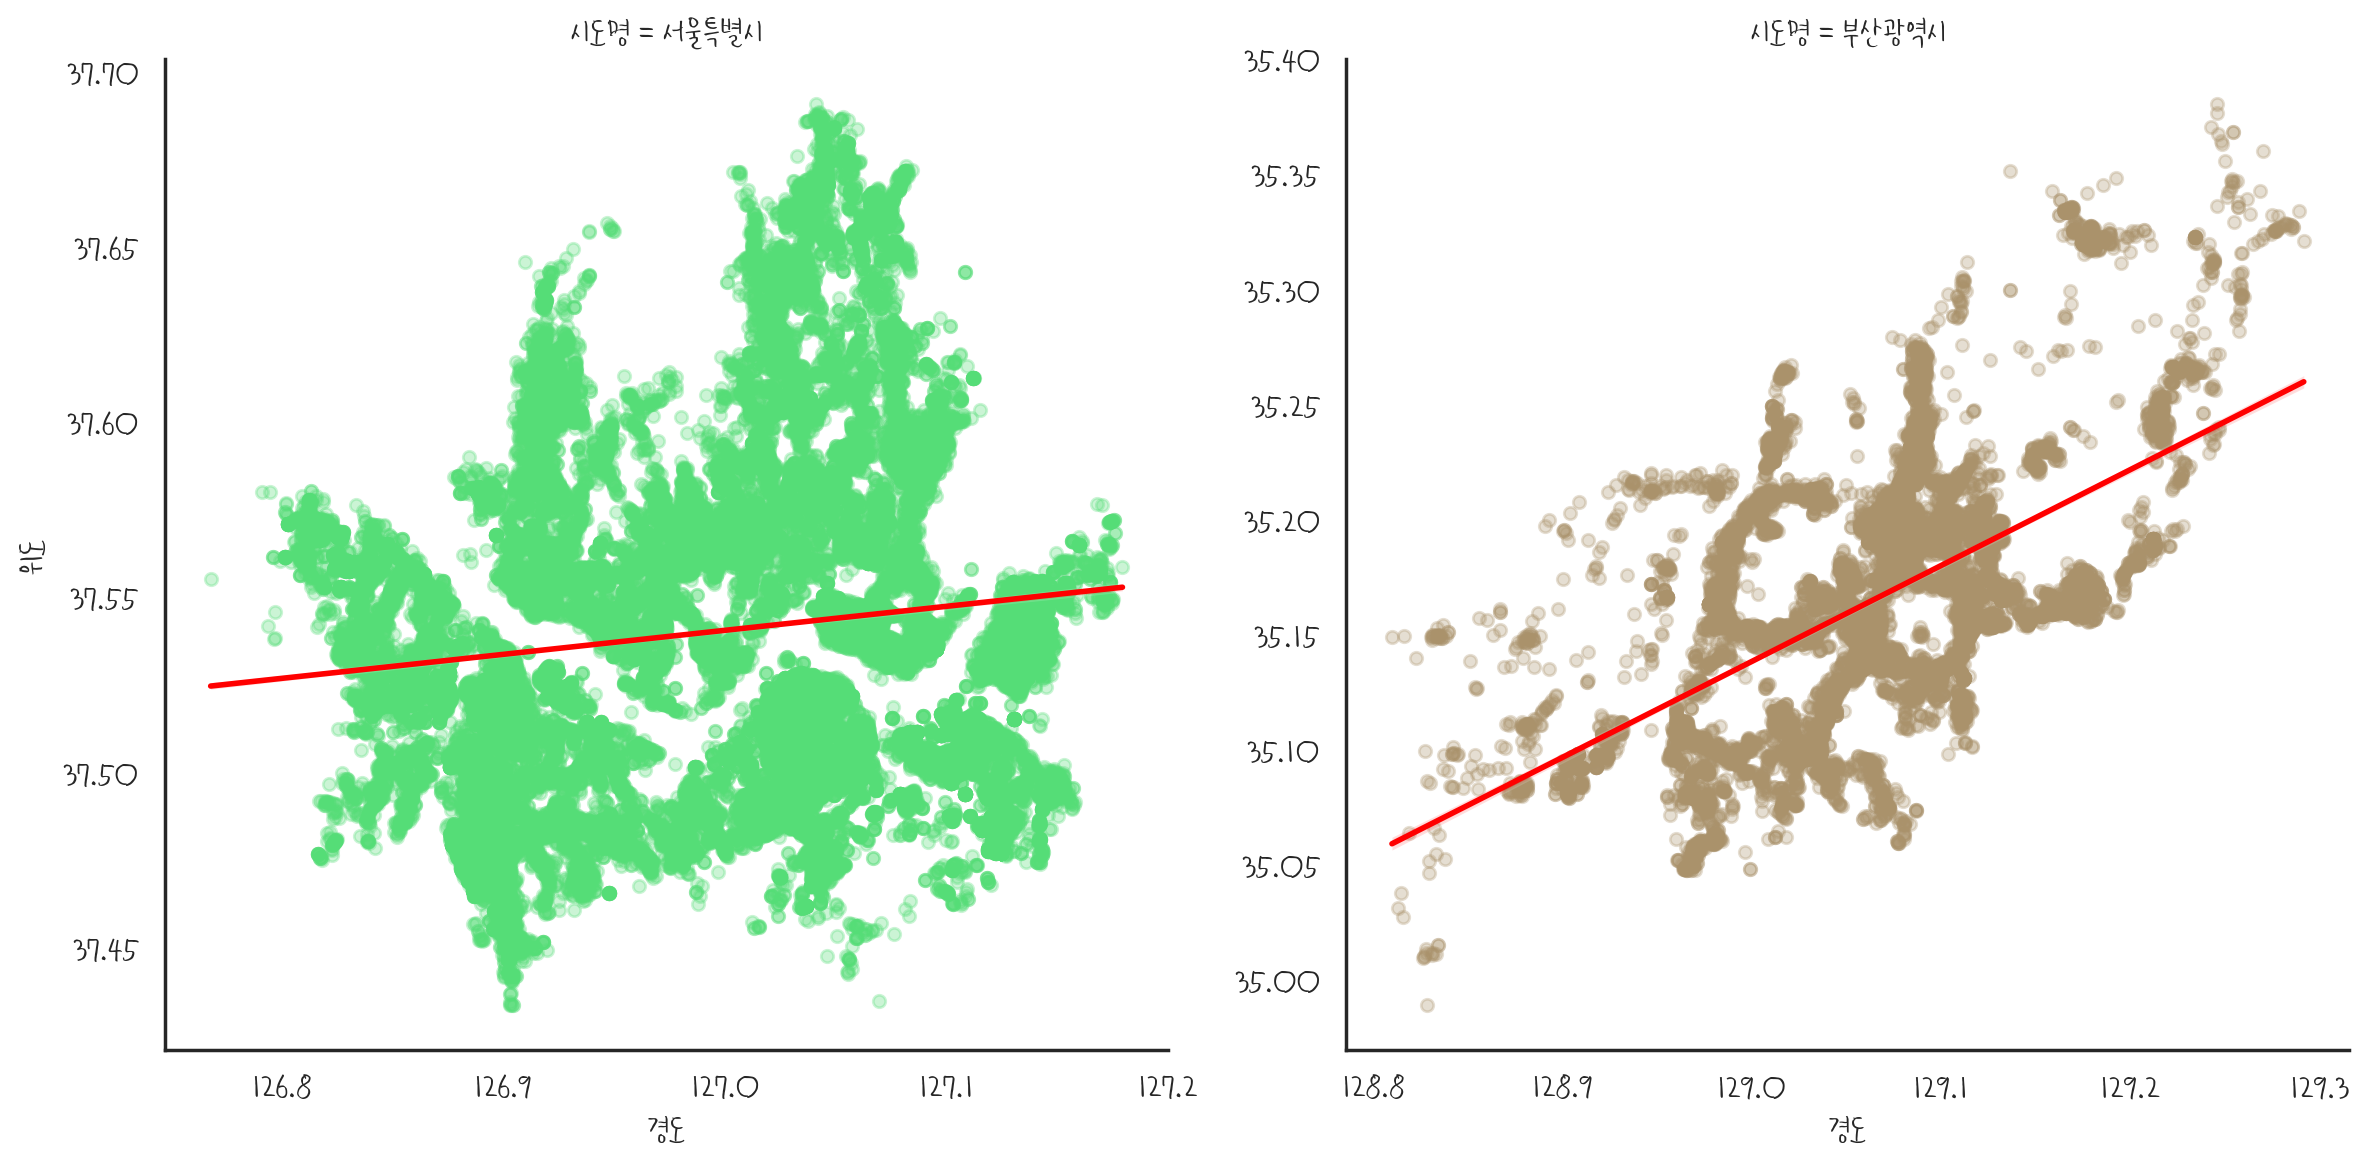

In [312]:
sns.lmplot(data=df.sample(frac=0.1), x='경도', y='위도', hue='시도명', col='시도명', palette='terrain',
            facet_kws={'sharex':False,'sharey':False}, height=6, aspect=1, legend=False, scatter_kws={"alpha": 0.3, "s": 20}, line_kws={"color": "red", "linewidth": 2})

plt.show()

# 10. 상권업종대분류명별 상호명의 개수를 도출하고 시각화하기

# 11. 상권업종대분류명이 음식인 서브셋을 이용한 분석
## ① “상권업종대분류명”이 음식인 서브셋을 변수 df_food에 할당하고 확인


## ②	“상권업종대분류명”이 음식이면서, "시군구명”이 강남구 데이터만 가져와 “상권업종중분류명”별로 빈도수를 구함(loc함수를 이용 vs loc함수 이용안함)

# 12.df 데이터셋에서 “상권업종대분류명”이 음식인 데이터 중 서울특별시 데이터 서브셋
- https://seaborn.pydata.org/tutorial/categorical.html : 범주형그래프
## ①	“상권업종대분류명”이 음식인 서브셋 중 서울특별시 데이터만 변수 df_seoul_food에 할당하고 확인


## ② df_seoul_food 데이터 셋을 시군구명, 상권업종중분류명으로 그룹화하여 상점수를 count한 내용을 food_gu 변수에 할당. 

## ③ df_seoul_food_gu 변수를 표로 출력(df_seoul_food_gu 이용하여 unstack).

## ④ 위 3번 스타일의 표를 pivot_table함수를 이용하여 출력

## ⑤ 3번의 결과 중 강남구 데이터만 뽑아 barplot으로 시각화(판다스 plot이용)

## ⑥ 3번 df_seoul_food_gu를 seaborn을 이용하여 구별 음식점 상호 개수를 시각화

## ⑦ 상권업종중분류명별 음식점 상호갯수

## ⑧	Seaborn의 catplot을 이용하여 상권업종중분류별 음식점을 구별로 시각화(서브플롯으로 시각화)

https://seaborn.pydata.org/tutorial/categorical.html

## ⑨	Seaborn의 catplot을 이용하여 구별 음식점을 상권업종중분류명별로 서브 플롯으로 시각화

# 13.	구별로 학원수 비교 : 서울 대치동이나 목동에 사교육이 발달되었다는 가설을 뒷받침할 수 있는 분석
## ① 서울시 교육(상권업종대분류명 이용) 데이터를 df_academy 변수에 할당하고 확인


## ②	df_academy 데이터 셋을 상호명별로 빈도수 출력(value_counts()함수 이용하거나 groupby이용)

## ③ df_academy 데이터 셋을 상호명별로 빈도수 상위 10개 출력

## ④ df_academy 데이터 셋을 시군구명 별로 빈도수 출력(학원이 가장 많은 구부터 출력)

## ⑤df_academy 데이터 셋에서 어떤 종류의 학원들이 많은지 상위10개만 academy_count변수에 할당하고 출력(상권업종소분류명 컬럼 이용)

## ⑥ df_academy 데이터셋에서 상권업종소분류명별로 빈도수를 구했을 때 빈도가 1000이상인 데이터만 따로 academy_count_1000변수에 할당

## ⑦ df_academy 데이터셋을 “시군구명”, "상권업종소분류명” 별 상호명 빈도수를 academy_group 변수에 할당 출력

## ⑧ academy_group 데이터셋에서 강남구 데이터만 출력 및 시각화(barplot)

## ⑨ df_academy데이터 중 “법정동명”컬럼이 “대치동”과 “목동”인 데이터만 가져와 상권업종소분류명별 빈도수 출력

## ⑩“상권업종소분류명”별 "시군구명” 별 상호명 빈도수를 g변수에 할당하고 출력

## ⑪ g변수의 내용중 "상권업종소분류명” 컬럼이 “입시·교과학원”데이터만 시각화(pandas의 plot.bar, pandas의 barh, seaborn의 barplot)

# 14. 서울시 데이터만 경도와 위도를 산점도로 시각화
## ① df_academy 데이터셋의 경도와 위도를 “시군명”별로 색상을 다르게 scatterplot으로 시각화


https://stackoverflow.com/questions/30490740/move-legend-outside-figure-in-seaborn-tsplot : 범례사용

## ② df_academy 데이터셋의 경도와 위도를 “상권업종소분류명”별로 색상을 다르게 scatterplot으로 시각화

## ③ df_academy 데이터셋 중 “입시·교과학원” 데이터만, 경도와 위도를 “시군구명”별로 색상을 다르게 scatterplot으로 시각화

## ④ df_academy 데이터셋 중 “태권도/무술학원” 데이터만, 경도와 위도를 “시군명”별로 색상을 다르게 scatterplot으로 시각화

## ⑤ df_academy 데이터셋 중 “입시·교과학원” 데이터와 “태권도/무술학원” 데이터만, 경도와 위도를 “상권업종소분류명”별로 색상을 다르게 scatterplot으로 시각화

# 15. 지도시각화 : Folium
` 아나콘다 프롬프트에서 아래의 둘 중 하나를 실행`

`pip install folium`

`conda install -c conda-forge folium`

-	docs : https://python-visualization.github.io/folium/latest/getting_started.html?utm_source=chatgpt.com
-	Quickstart : https://python-visualization.github.io/folium/version-v0.9.1/quickstart.html?utm_source=chatgpt.com


In [ ]:
# 태권도/무술학원과 입시·교과학원을 분리해서 지도 시각화